# Bank Marketing — Term Deposit Subscription Prediction

**Dataset:** UCI Bank Marketing Dataset (Portuguese retail bank, 2008–2010)

**Target:** Will the customer subscribe to a term deposit? (`y`: yes / no)

**Pipeline:** Data Loading → Cleaning & Preprocessing → EDA → Model Training → Evaluation → Feature Importance → Critical Reflection

## Section 0 — Setup & Imports

In [391]:
import subprocess
subprocess.run(['pip', 'install', 'xgboost', '--quiet'], check=True)
print('XGBoost ready.')

XGBoost ready.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [392]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score,
    cross_validate, GridSearchCV
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, precision_recall_fscore_support
)
from xgboost import XGBClassifier

sns.set_theme(style='whitegrid')
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

# Consistent colour palette used throughout
TEAL   = '#2a9d8f'
PURPLE = '#7b2d8b'
CORAL  = '#e76f51'
GRAY   = '#adb5bd'
AMBER  = '#e9c46a'

RANDOM_STATE = 42
print('All libraries loaded.')

All libraries loaded.


### Problem Framing

**What decision or process does this support?** The bank's outbound call-centre resource allocation: deciding *which customers to prioritise for contact* during a term deposit marketing campaign.

**What is the target variable?** `y` — whether a customer subscribes to a term deposit (`yes`/`no`), encoded as `1`/`0` in `y_enc`.

**Why is prediction useful?** Only ~18% of contacted customers subscribe. A model that identifies high-probability subscribers allows the bank to concentrate call-centre effort, reduce wasted contacts, and avoid alienating unlikely subscribers with repeated calls — directly improving campaign ROI without increasing budget.

## Section 1 — Data Loading & Initial Inspection

In [393]:
# New dataset: bank-additional-full.csv (semicolon delimited)
df = pd.read_csv('/Users/sharathraveendran/Desktop/MIBAT2/AI2/bank-additional-full.csv', sep=';')

print('Shape:', df.shape)
print('\nTarget distribution:')
print(df['y'].value_counts(normalize=True).round(3))
print('\nData Types:')
print(df.dtypes)
print('\nFirst 5 rows:')
print(df.head())
print('\nDescriptive Statistics:')
print(df.describe())
print('\nMissing Values:')
print(df.isnull().sum())

cat_cols = df.select_dtypes(include='object').columns.tolist()
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print('\nCategorical columns:', cat_cols)
print('Numerical  columns:', num_cols)

Shape: (41188, 21)

Target distribution:
y
no     0.887
yes    0.113
Name: proportion, dtype: float64

Data Types:
age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object

First 5 rows:
   age        job  marital    education  default housing loan    contact  \
0   56  housemaid  married     basic.4y       no      no   no  telephone   
1   57   services  married  high.school  unknown      no   no  telephone   
2   37   services  married  high.school       no     yes   no  telephone   
3   40

## Section 2 — Data Cleaning & Preprocessing

In [394]:
# Preserve a copy of the raw DataFrame for use in EDA (Section 3),
# where original categorical columns are still needed.
df_orig = df.copy()
df_orig['y_enc'] = df_orig['y'].map({'yes': 1, 'no': 0})

# --- 2a: Drop 'duration' (data leakage) ---
# 'duration' is the length of the last phone call in seconds.
# It is ONLY known AFTER the call ends, so it is unavailable at prediction
# time (i.e., when the bank decides whether to place the call).
# Including it would artificially inflate model performance; a real
# deployment could not use it. Removing it gives us an honest estimate.
df = df.drop(columns=['duration'])
print("'duration' dropped — data leakage prevention.")
print('Remaining columns:', df.shape[1])

'duration' dropped — data leakage prevention.
Remaining columns: 20


In [395]:
# --- 2b: Handle pdays ---
# pdays = 999 means the customer was NEVER previously contacted (approx. 96.3% of rows).
# Create a binary flag to capture this meaningful distinction explicitly.
df['has_been_contacted'] = (df['pdays'] != 999).astype(int)

print(f'Previously contacted: {df["has_been_contacted"].mean()*100:.1f}%')
print('Note: new dataset encodes never-contacted as 999 (was -1 in old dataset)')

Previously contacted: 3.7%
Note: new dataset encodes never-contacted as 999 (was -1 in old dataset)


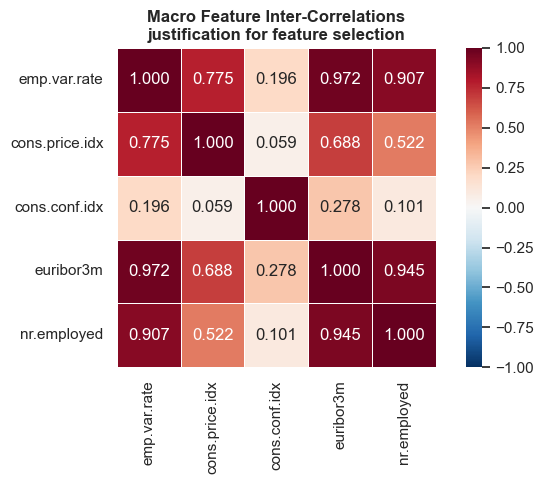

Pairwise correlations:
                emp.var.rate  cons.price.idx  cons.conf.idx  euribor3m  \
emp.var.rate           1.000           0.775          0.196      0.972   
cons.price.idx         0.775           1.000          0.059      0.688   
cons.conf.idx          0.196           0.059          1.000      0.278   
euribor3m              0.972           0.688          0.278      1.000   
nr.employed            0.907           0.522          0.101      0.945   

                nr.employed  
emp.var.rate          0.907  
cons.price.idx        0.522  
cons.conf.idx         0.101  
euribor3m             0.945  
nr.employed           1.000  


In [396]:
# --- Macro feature inter-correlations — justification for feature selection ---
macro_cols = ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
              'euribor3m', 'nr.employed']
macro_corr = df_orig[macro_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    macro_corr,
    annot=True, fmt='.3f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax, square=True
)
ax.set_title(
    'Macro Feature Inter-Correlations\n'
    'justification for feature selection',
    fontweight='bold', fontsize=12
)
plt.tight_layout()
plt.savefig('plot_macro_correlations.png', dpi=150, bbox_inches='tight')
plt.show()
print('Pairwise correlations:')
print(macro_corr.round(3))

### Section 2.1 — Macro Feature Selection

**`emp.var.rate`, `euribor3m`, and `nr.employed`** have pairwise correlations of
**0.907–0.972** — severe multicollinearity that destabilises Logistic Regression
coefficients and introduces redundant splits in tree models.

We **retain `euribor3m`** (strongest individual correlation with target: −0.308)
and **`cons.conf.idx`** (the only genuinely independent macro feature), and
**drop `emp.var.rate`, `cons.price.idx`, and `nr.employed`**.
`cons.price.idx` is highly correlated with `euribor3m` (0.688) and adds limited
independent signal.

In a production setting, PCA on the macro feature block would be the principled approach.

In [397]:
# Drop three highly collinear macro features
# emp.var.rate, euribor3m, and nr.employed have inter-correlations of 0.907-0.972.
# We retain euribor3m (strongest individual correlation with target: -0.308) and
# cons.conf.idx (genuinely independent macro feature). cons.price.idx is dropped
# as it is highly correlated with euribor3m (0.688) and adds limited independent signal.
df.drop(columns=['emp.var.rate', 'cons.price.idx', 'nr.employed'], inplace=True)
print('Retained macro features: euribor3m, cons.conf.idx')
print(f'euribor3m     — mean: {df["euribor3m"].mean():.3f}')
print(f'cons.conf.idx — mean: {df["cons.conf.idx"].mean():.3f}')

Retained macro features: euribor3m, cons.conf.idx
euribor3m     — mean: 3.621
cons.conf.idx — mean: -40.503


In [398]:
# --- 2c: Encode target variable ---
df['y_enc'] = df['y'].map({'yes': 1, 'no': 0})
print('Target encoded: yes=1, no=0')
print(df['y_enc'].value_counts())

Target encoded: yes=1, no=0
y_enc
0    36548
1     4640
Name: count, dtype: int64


## Section 2.5 — Feature Engineering

All new features are derived from existing columns and applied to `df` before encoding.
Rationale is documented inline. New categorical features are added to `multi_cols`
for one-hot encoding in Section 2d; new numerical features require no additional encoding.

| Feature | Type | Replaces / augments |
|---|---|---|
| `education_ord` | Ordinal (0–6) | Replaces one-hot `education` |
| `contact_recency` | Categorical (4 bins) | Augments `pdays` + `has_been_contacted` |
| `debt_burden` | Numeric (0/1/2) | Combines `housing` + `loan` |
| `log_campaign` | Numeric | Log-transform of `campaign` (replaces raw) |
| `job_stability` | Categorical (3 groups) | Augments fine-grained `job` dummies |
| `age_group` | Categorical (5 bins) | Augments raw `age` |
| `relationship_quality` | Numeric (0–3) | Combines recency + outcome signal |
| `high_value_segment` | Binary | Student/retired or age > 60 |
| `age_job_segment` | Categorical | `age_group` × `job_stability` interaction |
| `highval_x_euribor` | Numeric | `high_value_segment` × `euribor3m` |
| `euribor_x_financial` | Numeric | `euribor3m` × `(2 − debt_burden)` wealth proxy |
| `warmth_x_wealth` | Numeric | `relationship_quality` × `debt_burden` |

> **`financial_health` evaluated and excluded as a direct feature:** subscription rates
> across its three levels were 11.1%, 11.6%, and 10.9% — a spread of < 1 pp, below the
> 3 pp threshold. However, `euribor_x_financial` and `warmth_x_wealth` are **retained**
> as interactions using `debt_burden` (the component that retains discriminatory signal).

In [399]:
# --- 2.5a: Education ordinal encoding ---
# Education has a natural ordering from illiterate to university degree.
# Ordinal encoding preserves this structure; one-hot would treat it as nominal.
education_order = {
    'illiterate':          0,
    'basic.4y':            1,
    'basic.6y':            2,
    'basic.9y':            3,
    'high.school':         4,
    'professional.course': 5,
    'university.degree':   6,
    'unknown':             3   # impute to median level
}
df['education_ord'] = df['education'].map(education_order)
df.drop(columns=['education'], inplace=True)
# Also drop from df_orig so encoding cell stays consistent
df_orig['education_ord'] = df_orig['education'].map(education_order)
print('Education encoded ordinally (0=illiterate → 6=university.degree)')
print(df['education_ord'].value_counts().sort_index())

Education encoded ordinally (0=illiterate → 6=university.degree)
education_ord
0       18
1     4176
2     2292
3     7776
4     9515
5     5243
6    12168
Name: count, dtype: int64


In [400]:
# --- 2.5b: Contact recency buckets ---
# pdays = 999 means never contacted (new dataset encoding).
# Binning captures genuinely different customer states:
# never-touched vs. warm vs. cooling-off vs. cold.
def contact_recency(pdays):
    if pdays == 999:
        return 'never'
    elif pdays <= 30:
        return 'recent'    # contacted within last month
    elif pdays <= 90:
        return 'medium'    # contacted 1-3 months ago
    else:
        return 'distant'   # contacted 3+ months ago

df['contact_recency'] = df['pdays'].apply(contact_recency)
print('Contact recency distribution:')
print(df['contact_recency'].value_counts())

Contact recency distribution:
contact_recency
never     39673
recent     1515
Name: count, dtype: int64


In [401]:
# --- 2.5c: Debt burden indicator ---
# Customers with both a housing loan and a personal loan face higher
# financial commitments and may be less willing to lock funds away.
# Uses df_orig since housing/loan are still strings at this point.
df['debt_burden'] = (
    (df_orig['housing'] == 'yes').astype(int) +
    (df_orig['loan'] == 'yes').astype(int)
)  # 0 = no debt, 1 = one loan, 2 = both loans
print('Debt burden distribution:')
print(df['debt_burden'].value_counts())

Debt burden distribution:
debt_burden
1    20442
0    17055
2     3691
Name: count, dtype: int64


In [402]:
# --- 2.5e: log_campaign (replaces raw campaign) ---
# Campaign contact counts are right-skewed (most customers contacted 1-3 times,
# some up to 56 times). Log-transforming compresses the tail and improves
# linearity for Logistic Regression without losing information.
df['log_campaign'] = np.log1p(df['campaign'])
df.drop(columns=['campaign'], inplace=True)
print(f'log_campaign — mean: {df["log_campaign"].mean():.3f}, '
      f'max: {df["log_campaign"].max():.3f}')

log_campaign — mean: 1.119, max: 4.043


In [403]:
# --- 2.5e: Job stability grouping ---
# 11 job categories contain redundant granularity. Group into three tiers
# reflecting financial stability and likelihood of discretionary savings.
job_stability_map = {
    'management':    'stable',
    'technician':    'stable',
    'admin.':        'stable',
    'self-employed': 'stable',
    'entrepreneur':  'stable',
    'retired':       'transitional',
    'student':       'transitional',
    'housemaid':     'vulnerable',
    'blue-collar':   'vulnerable',
    'services':      'vulnerable',
    'unemployed':    'vulnerable',
    'unknown':       'unknown'
}
df['job_stability'] = df_orig['job'].map(job_stability_map)
print('Job stability distribution:')
print(df['job_stability'].value_counts())

Job stability distribution:
job_stability
stable          22966
vulnerable      15297
transitional     2595
unknown           330
Name: count, dtype: int64


In [404]:
# --- 2.5f: Age group bins ---
# Subscription rates differ substantially across life stages.
# Binning age into 5 groups captures non-linear effects and
# enables the age_job_segment interaction feature.
bins   = [17, 30, 40, 50, 60, 100]
labels = ['18-30', '30-40', '40-50', '50-60', '60+']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=True, include_lowest=True)

print('Age group subscription rates:')
print(df.groupby('age_group', observed=True)['y_enc'].mean()
      .apply(lambda x: f'{x*100:.1f}%'))

Age group subscription rates:
age_group
18-30    15.2%
30-40     9.7%
40-50     8.2%
50-60    10.7%
60+      45.5%
Name: y_enc, dtype: object


In [405]:
# --- 2.5g: Relationship quality score ---
# Combines previous outcome and recency into a single ordinal score (0-3).
# Captures the full warm-lead signal: poutcome=success is strongest,
# followed by recent prior contact, then any prior contact.
def relationship_quality(row):
    if row['poutcome'] == 'success':
        return 3
    elif row['has_been_contacted'] == 1 and row['contact_recency'] == 'recent':
        return 2
    elif row['has_been_contacted'] == 1:
        return 1
    else:
        return 0

df['relationship_quality'] = df.apply(relationship_quality, axis=1)
print('Relationship quality distribution:')
print(df['relationship_quality'].value_counts().sort_index())
print('\nSubscription rate by relationship_quality:')
print(df.groupby('relationship_quality')['y_enc'].mean().apply(lambda x: f'{x*100:.1f}%'))

Relationship quality distribution:
relationship_quality
0    39673
2      142
3     1373
Name: count, dtype: int64

Subscription rate by relationship_quality:
relationship_quality
0     9.3%
2    51.4%
3    65.1%
Name: y_enc, dtype: object


In [406]:
# --- 2.5h: High-value segment flag ---
# Students and retired customers show consistently elevated conversion rates
# in EDA. Customers over 60 also skew toward subscription.
# Note: balance is not available in this dataset, so the flag uses
# job type and age only.
df['high_value_segment'] = (
    (df_orig['job'].isin(['student', 'retired'])) |
    (df_orig['age'] > 60)
).astype(int)
print(f'High-value segment: {df["high_value_segment"].mean()*100:.1f}% of customers')
hv_rate = df.groupby('high_value_segment')['y_enc'].mean()
print('Subscription rate — high_value_segment=0:', f'{hv_rate[0]*100:.1f}%')
print('Subscription rate — high_value_segment=1:', f'{hv_rate[1]*100:.1f}%')

High-value segment: 6.9% of customers
Subscription rate — high_value_segment=0: 10.0%
Subscription rate — high_value_segment=1: 28.7%


In [407]:
# --- 2.5i: Interaction features ---

# Interaction 1: age_group × job_stability
# Life stage combined with employment stability is a strong proxy for
# discretionary savings capacity.
df['age_job_segment'] = df['age_group'].astype(str) + '_' + df['job_stability'].astype(str)

print('age_job_segment subscription rates (top 10 by rate):')
seg_rates = df.groupby('age_job_segment')['y_enc'].mean().sort_values(ascending=False)
print(seg_rates.head(10).apply(lambda x: f'{x*100:.1f}%'))

# Interaction 2: high_value_segment × euribor3m
# High-value demographic groups are even more sensitive to the rate environment.
df['highval_x_euribor'] = df['high_value_segment'] * df['euribor3m']

# Interaction 3: euribor3m × debt-based wealth proxy
# (2 - debt_burden) maps 0 loans→2, 1 loan→1, 2 loans→0.
# Wealthier (low-debt) clients react more strongly to the rate environment.
df['euribor_x_financial'] = df['euribor3m'] * (2 - df['debt_burden'])

# Interaction 4: relationship quality × financial pressure
# Clients with both warm prior contact AND low debt burden are most receptive.
df['warmth_x_wealth'] = df['relationship_quality'] * df['debt_burden'].clip(lower=0)

print('\nInteraction features created: age_job_segment, highval_x_euribor,')
print('                               euribor_x_financial, warmth_x_wealth')

age_job_segment subscription rates (top 10 by rate):
age_job_segment
60+_stable            46.9%
60+_transitional      46.2%
60+_vulnerable        39.8%
60+_unknown           38.1%
18-30_transitional    32.9%
18-30_unknown         27.3%
30-40_transitional    18.8%
18-30_stable          15.6%
50-60_transitional    12.3%
50-60_stable          11.7%
Name: y_enc, dtype: object

Interaction features created: age_job_segment, highval_x_euribor,
                               euribor_x_financial, warmth_x_wealth


In [408]:
# --- 2.5j: Engineered features validation summary ---
# Check that each feature shows meaningful variation in subscription rate.
# Note: financial_health was evaluated and showed subscription rates of 11.1%, 11.6%,
# and 10.9% across its three levels — a spread of < 1 pp, below the 3 pp threshold.
# It was excluded as a direct feature; however euribor_x_financial and warmth_x_wealth
# are retained as interactions using debt_burden (the component with discriminatory power).
new_features_cat = ['contact_recency', 'job_stability', 'age_group', 'age_job_segment']
new_features_num = ['education_ord', 'debt_burden',
                     'log_campaign', 'relationship_quality', 'high_value_segment',
                     'euribor3m', 'cons.conf.idx', 'highval_x_euribor',
                     'euribor_x_financial', 'warmth_x_wealth']

print('=== Engineered Features — Subscription Rate Validation ===')
for feat in new_features_cat:
    print(f'\n{feat}:')
    rates = df.groupby(feat, observed=True)['y_enc'].mean().sort_values(ascending=False)
    for val, rate in rates.items():
        print(f'  {str(val):<20}: {rate*100:.1f}% subscription rate')

print()
for feat in new_features_num:
    corr = df[feat].corr(df['y_enc'])
    print(f'  {feat:<28} mean={df[feat].mean():.3f}  corr_with_target={corr:.3f}')

=== Engineered Features — Subscription Rate Validation ===

contact_recency:
  recent              : 63.8% subscription rate
  never               : 9.3% subscription rate

job_stability:
  transitional        : 27.3% subscription rate
  stable              : 11.7% subscription rate
  unknown             : 11.2% subscription rate
  vulnerable          : 7.9% subscription rate

age_group:
  60+                 : 45.5% subscription rate
  18-30               : 15.2% subscription rate
  50-60               : 10.7% subscription rate
  30-40               : 9.7% subscription rate
  40-50               : 8.2% subscription rate

age_job_segment:
  60+_stable          : 46.9% subscription rate
  60+_transitional    : 46.2% subscription rate
  60+_vulnerable      : 39.8% subscription rate
  60+_unknown         : 38.1% subscription rate
  18-30_transitional  : 32.9% subscription rate
  18-30_unknown       : 27.3% subscription rate
  30-40_transitional  : 18.8% subscription rate
  18-30_stable   

In [409]:
# Save engineered categorical features for CatBoost BEFORE one-hot encoding removes them.
# get_dummies() with drop_first=True drops the original categorical columns from df.
_saved_cat_feats_for_catboost = {
    'contact_recency':  df['contact_recency'].copy(),
    'job_stability':     df['job_stability'].copy(),
    'age_group':         df['age_group'].astype(str).copy(),
    'age_job_segment':   df['age_job_segment'].astype(str).copy(),
}
print('Categorical features saved for CatBoost:', list(_saved_cat_feats_for_catboost.keys()))

Categorical features saved for CatBoost: ['contact_recency', 'job_stability', 'age_group', 'age_job_segment']


In [410]:
# --- 2d: Encode categorical variables ---

# Binary columns: Label Encode
binary_cols = ['default', 'housing', 'loan', 'contact']
le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

# Multi-class columns: One-Hot Encode (drop_first avoids multicollinearity)
# 'education' replaced by ordinal 'education_ord'; 'campaign' replaced by 'log_campaign'.
# 'day_of_week' added from new dataset. 'month_quarter' removed (month kept).
multi_cols = [
    'job', 'marital', 'month', 'day_of_week', 'poutcome',  # original (no education)
    'contact_recency', 'job_stability', 'age_group', 'age_job_segment'  # engineered
]
df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

# Convert boolean dummy columns to int (pandas 2.x returns bool by default)
bool_cols = df.select_dtypes(include='bool').columns.tolist()
if bool_cols:
    df[bool_cols] = df[bool_cols].astype(int)

# Drop original target string column
df = df.drop(columns=['y'])

print('Encoding complete. Shape:', df.shape)
print('\nAll columns:')
print(df.columns.tolist())

Encoding complete. Shape: (41188, 75)

All columns:
['age', 'default', 'housing', 'loan', 'contact', 'pdays', 'previous', 'cons.conf.idx', 'euribor3m', 'has_been_contacted', 'y_enc', 'education_ord', 'debt_burden', 'log_campaign', 'relationship_quality', 'high_value_segment', 'highval_x_euribor', 'euribor_x_financial', 'warmth_x_wealth', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'job_unknown', 'marital_married', 'marital_single', 'marital_unknown', 'month_aug', 'month_dec', 'month_jul', 'month_jun', 'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep', 'day_of_week_mon', 'day_of_week_thu', 'day_of_week_tue', 'day_of_week_wed', 'poutcome_nonexistent', 'poutcome_success', 'contact_recency_recent', 'job_stability_transitional', 'job_stability_unknown', 'job_stability_vulnerable', 'age_group_30-40', 'age_group_40-50', 'age_group_50-60', 'age_grou

In [411]:
# --- 2e: Define feature matrix X and target vector y ---
X = df.drop(columns=['y_enc'])
y = df['y_enc']

print('X shape:', X.shape)
print(f'\nAll {len(X.columns)} feature names:')
for i, col in enumerate(X.columns, 1):
    print(f'  {i:2d}. {col}')

X shape: (41188, 74)

All 74 feature names:
   1. age
   2. default
   3. housing
   4. loan
   5. contact
   6. pdays
   7. previous
   8. cons.conf.idx
   9. euribor3m
  10. has_been_contacted
  11. education_ord
  12. debt_burden
  13. log_campaign
  14. relationship_quality
  15. high_value_segment
  16. highval_x_euribor
  17. euribor_x_financial
  18. warmth_x_wealth
  19. job_blue-collar
  20. job_entrepreneur
  21. job_housemaid
  22. job_management
  23. job_retired
  24. job_self-employed
  25. job_services
  26. job_student
  27. job_technician
  28. job_unemployed
  29. job_unknown
  30. marital_married
  31. marital_single
  32. marital_unknown
  33. month_aug
  34. month_dec
  35. month_jul
  36. month_jun
  37. month_mar
  38. month_may
  39. month_nov
  40. month_oct
  41. month_sep
  42. day_of_week_mon
  43. day_of_week_thu
  44. day_of_week_tue
  45. day_of_week_wed
  46. poutcome_nonexistent
  47. poutcome_success
  48. contact_recency_recent
  49. job_stability_tra

In [412]:
# --- 2f: Confirm zero NaN values ---
nan_count = X.isnull().sum().sum()
if nan_count > 0:
    raise ValueError(
        f'Feature matrix X contains {nan_count} NaN values. '
        'Investigate and fix before modelling.'
    )
print(f'NaN check passed: {nan_count} missing values in X.')

NaN check passed: 0 missing values in X.


## Section 3 — Exploratory Data Analysis

All visualisations use `df_orig` — the raw DataFrame retained before encoding — so that original categorical labels remain readable.

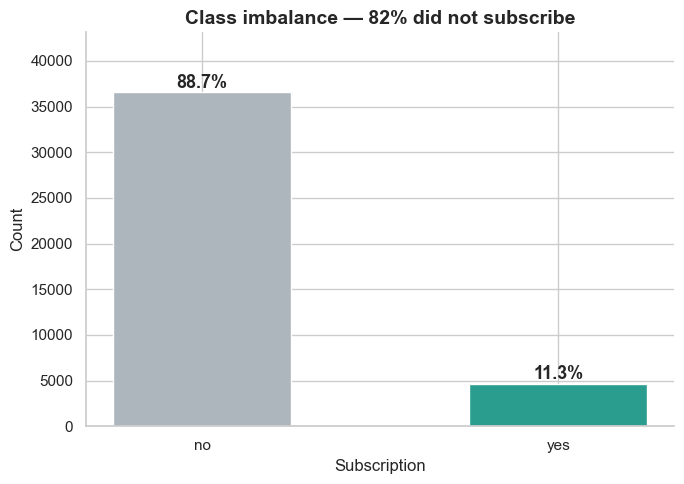

Plot 1 saved.


In [413]:
# --- Plot 1: Target class distribution ---
counts = df_orig['y'].value_counts()
bar_colors = [GRAY if lbl == 'no' else TEAL for lbl in counts.index]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(counts.index, counts.values, color=bar_colors,
              edgecolor='white', width=0.5)
for bar, val in zip(bars, counts.values):
    pct = val / counts.sum() * 100
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 40,
        f'{pct:.1f}%',
        ha='center', va='bottom', fontweight='bold', fontsize=13
    )
ax.set_title('Class imbalance — 82% did not subscribe', fontsize=14, fontweight='bold')
ax.set_xlabel('Subscription', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_ylim(0, counts.max() * 1.18)
# Because of this imbalance, accuracy is not our primary metric.
# A model that always predicts 'No' would achieve ~88% accuracy but be useless.
# We use F1-weighted and ROC-AUC instead.
plt.tight_layout()
plt.savefig('plot1_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot 1 saved.')

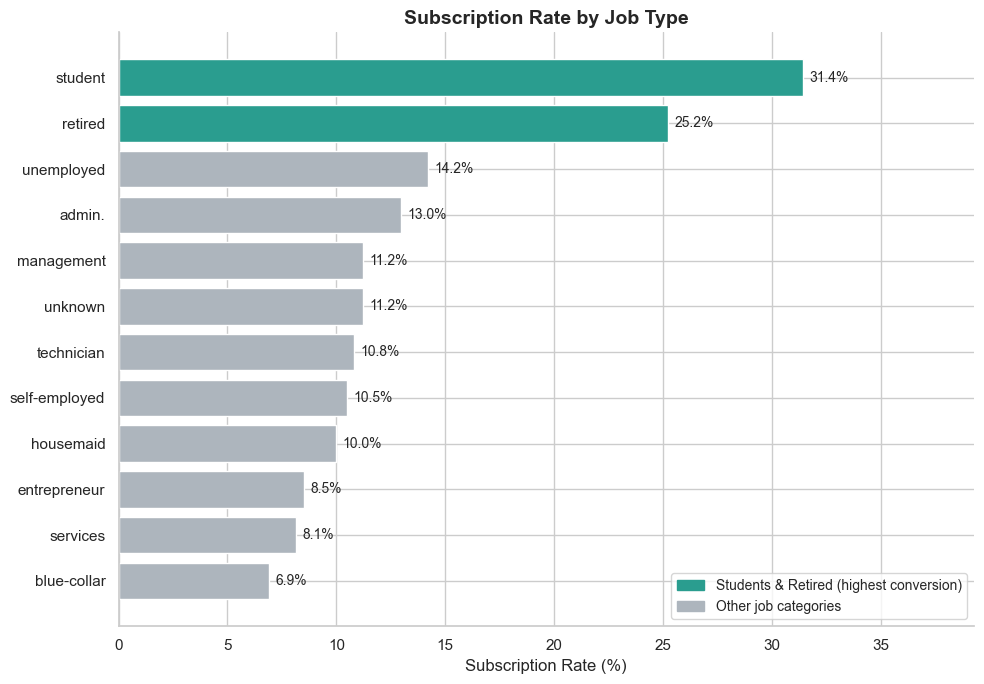

Plot 2 saved.


In [414]:
# --- Plot 2: Subscription rate by job type ---
job_rate = (df_orig.groupby('job')['y_enc'].mean() * 100).sort_values(ascending=True)
highlight = ['student', 'retired']
bar_colors = [TEAL if j in highlight else GRAY for j in job_rate.index]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(job_rate.index, job_rate.values, color=bar_colors)
for bar, val in zip(bars, job_rate.values):
    ax.text(
        val + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.1f}%', va='center', fontsize=10
    )
ax.set_xlabel('Subscription Rate (%)', fontsize=12)
ax.set_title('Subscription Rate by Job Type', fontsize=14, fontweight='bold')
ax.set_xlim(0, job_rate.max() * 1.25)
legend_elements = [
    mpatches.Patch(color=TEAL, label='Students & Retired (highest conversion)'),
    mpatches.Patch(color=GRAY, label='Other job categories')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)
plt.tight_layout()
plt.savefig('plot2_subscription_by_job.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot 2 saved.')

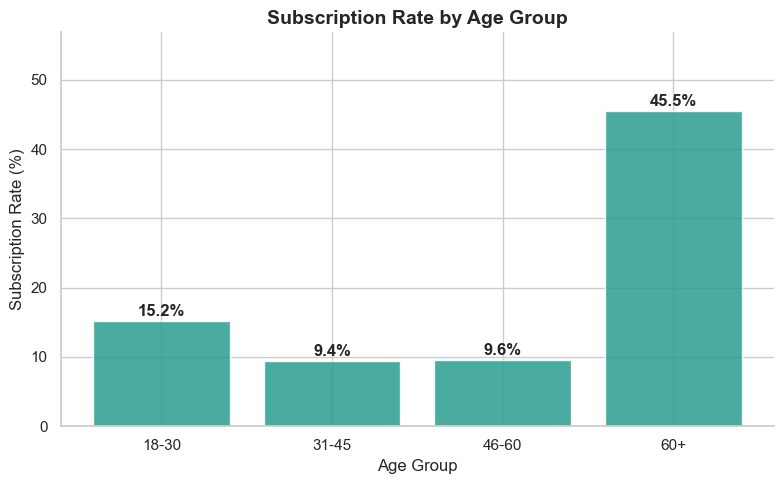

Plot 3 saved.


In [415]:
# --- Plot 3: Subscription rate by age group ---
bins   = [17, 30, 45, 60, 120]
labels = ['18-30', '31-45', '46-60', '60+']
df_orig['age_group'] = pd.cut(
    df_orig['age'], bins=bins, labels=labels,
    right=True, include_lowest=True
)
age_rate = (
    df_orig.groupby('age_group', observed=True)['y_enc'].mean() * 100
)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    age_rate.index.astype(str), age_rate.values,
    color=TEAL, edgecolor='white', alpha=0.85
)
for bar, val in zip(bars, age_rate.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{val:.1f}%', ha='center', va='bottom',
        fontweight='bold', fontsize=12
    )
ax.set_xlabel('Age Group', fontsize=12)
ax.set_ylabel('Subscription Rate (%)', fontsize=12)
ax.set_title('Subscription Rate by Age Group', fontsize=14, fontweight='bold')
ax.set_ylim(0, age_rate.max() * 1.25)
plt.tight_layout()
plt.savefig('plot3_subscription_by_age.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot 3 saved.')

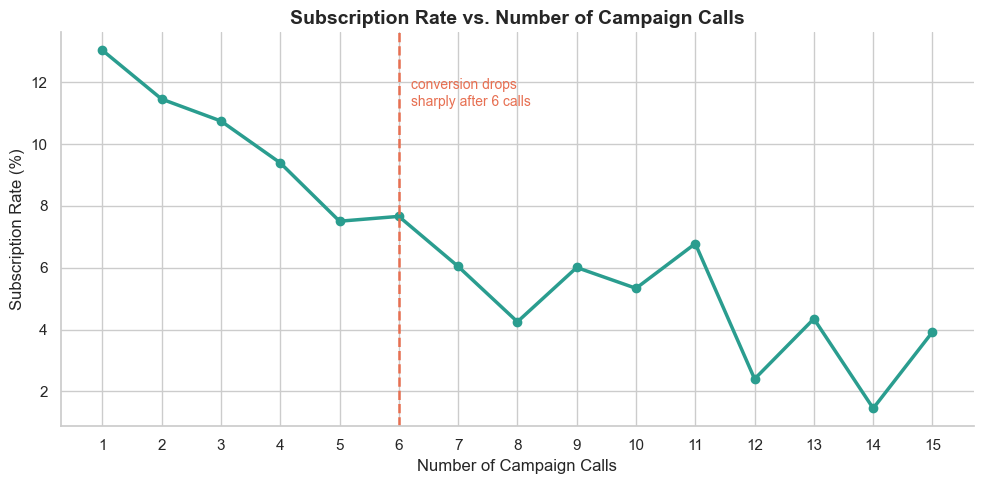

Plot 4 saved.


In [416]:
# --- Plot 4: Subscription rate vs. number of campaign calls ---
df_camp  = df_orig[df_orig['campaign'] <= 15].copy()
camp_rate = (df_camp.groupby('campaign')['y_enc'].mean() * 100)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(
    camp_rate.index, camp_rate.values,
    color=TEAL, linewidth=2.5, marker='o', markersize=6
)
ax.axvline(x=6, color=CORAL, linestyle='--', linewidth=1.8)
ax.text(
    6.2, camp_rate.max() * 0.93,
    'conversion drops\nsharply after 6 calls',
    color=CORAL, fontsize=10, va='top'
)
ax.set_xlabel('Number of Campaign Calls', fontsize=12)
ax.set_ylabel('Subscription Rate (%)', fontsize=12)
ax.set_title('Subscription Rate vs. Number of Campaign Calls', fontsize=14, fontweight='bold')
ax.set_xticks(range(1, 16))
plt.tight_layout()
plt.savefig('plot4_subscription_vs_calls.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot 4 saved.')

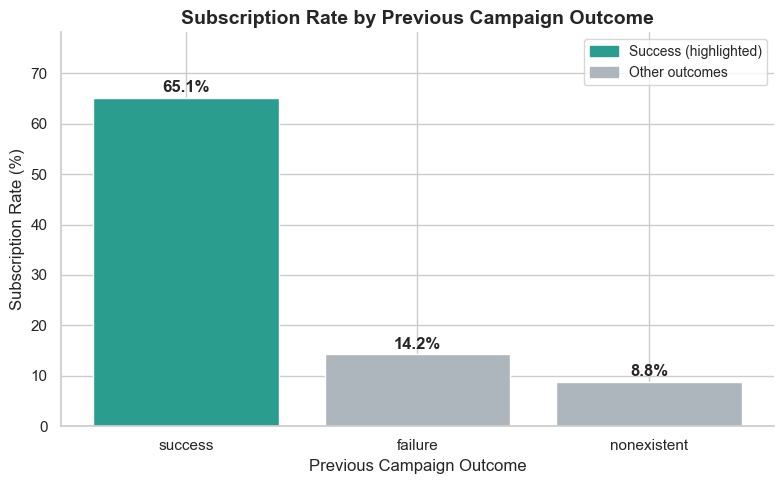

Plot 5 saved.


In [417]:
# --- Plot 5: Previous campaign outcome vs subscription ---
pout_rate = (
    df_orig.groupby('poutcome')['y_enc'].mean() * 100
).sort_values(ascending=False)
bar_colors = [TEAL if p == 'success' else GRAY for p in pout_rate.index]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(pout_rate.index, pout_rate.values,
              color=bar_colors, edgecolor='white')
for bar, val in zip(bars, pout_rate.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{val:.1f}%', ha='center', va='bottom',
        fontweight='bold', fontsize=12
    )
ax.set_xlabel('Previous Campaign Outcome', fontsize=12)
ax.set_ylabel('Subscription Rate (%)', fontsize=12)
ax.set_title('Subscription Rate by Previous Campaign Outcome',
             fontsize=14, fontweight='bold')
ax.set_ylim(0, pout_rate.max() * 1.2)
legend_elements = [
    mpatches.Patch(color=TEAL, label='Success (highlighted)'),
    mpatches.Patch(color=GRAY, label='Other outcomes')
]
ax.legend(handles=legend_elements, fontsize=10)
plt.tight_layout()
plt.savefig('plot5_subscription_by_poutcome.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot 5 saved.')

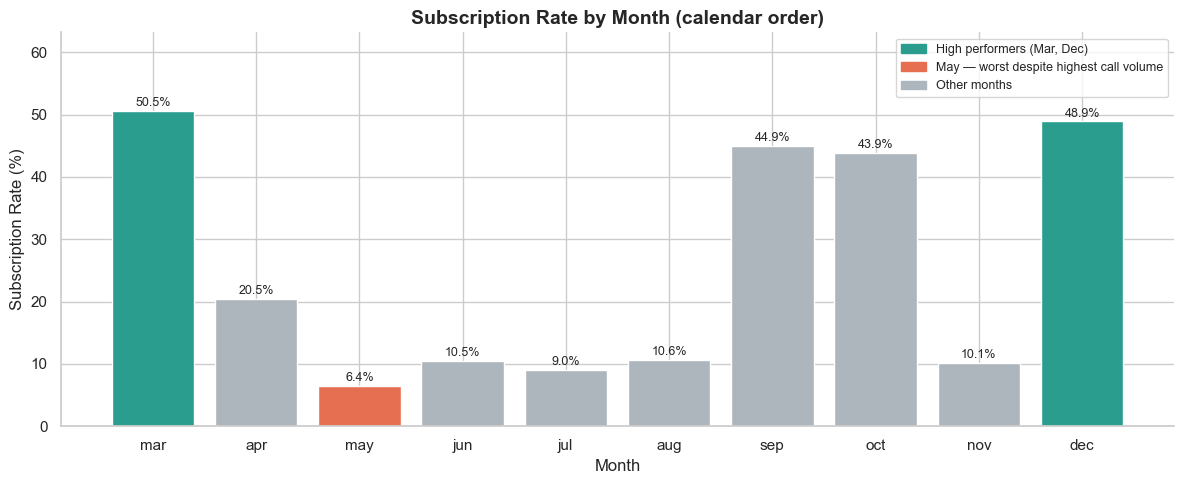

Plot 6 saved.


In [418]:
# --- Plot 6: Subscription rate by month (calendar order) ---
month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun',
               'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
months_present = [m for m in month_order if m in df_orig['month'].unique()]
month_rate = (
    df_orig.groupby('month')['y_enc'].mean() * 100
).reindex(months_present)

teal_months  = ['mar', 'dec']
coral_months = ['may']
bar_colors = []
for m in months_present:
    if m in teal_months:
        bar_colors.append(TEAL)
    elif m in coral_months:
        bar_colors.append(CORAL)
    else:
        bar_colors.append(GRAY)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(months_present, month_rate.values,
              color=bar_colors, edgecolor='white')
for bar, val in zip(bars, month_rate.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{val:.1f}%', ha='center', va='bottom', fontsize=9
    )
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Subscription Rate (%)', fontsize=12)
ax.set_title('Subscription Rate by Month (calendar order)',
             fontsize=14, fontweight='bold')
ax.set_ylim(0, month_rate.max() * 1.25)
legend_elements = [
    mpatches.Patch(color=TEAL,  label='High performers (Mar, Dec)'),
    mpatches.Patch(color=CORAL, label='May — worst despite highest call volume'),
    mpatches.Patch(color=GRAY,  label='Other months')
]
ax.legend(handles=legend_elements, fontsize=9, loc='upper right')
plt.tight_layout()
plt.savefig('plot6_subscription_by_month.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot 6 saved.')

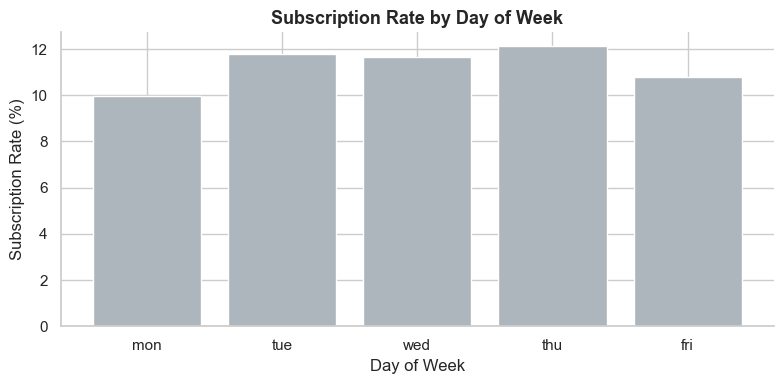

Day-of-week rate range: 9.9% - 12.1%
Plot saved: plot_day_analysis.png


In [419]:
# --- Plot: Subscription rate by day of week ---
# bank-additional-full.csv uses day_of_week (mon-fri), not day-of-month.
day_order = ['mon', 'tue', 'wed', 'thu', 'fri']
day_rate = (
    df_orig[df_orig['day_of_week'].isin(day_order)]
    .groupby('day_of_week')['y_enc'].mean() * 100
).reindex(day_order)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(day_rate.index, day_rate.values, color=GRAY, edgecolor='white')
ax.set_xlabel('Day of Week', fontsize=12)
ax.set_ylabel('Subscription Rate (%)', fontsize=12)
ax.set_title(
    'Subscription Rate by Day of Week',
    fontweight='bold', fontsize=13
)
plt.tight_layout()
plt.savefig('plot_day_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Day-of-week rate range: {day_rate.min():.1f}% - {day_rate.max():.1f}%')
print('Plot saved: plot_day_analysis.png')

**Note on `day_of_week`:** The new dataset includes day of the week (Mon–Fri) rather
than day of the month. Day-of-week reflects campaign scheduling patterns and may
capture whether certain days see different customer receptivity. However, like
day-of-month, it reflects *when the bank chose to call* more than an intrinsic
customer property. Monitor for stability across deployment periods.

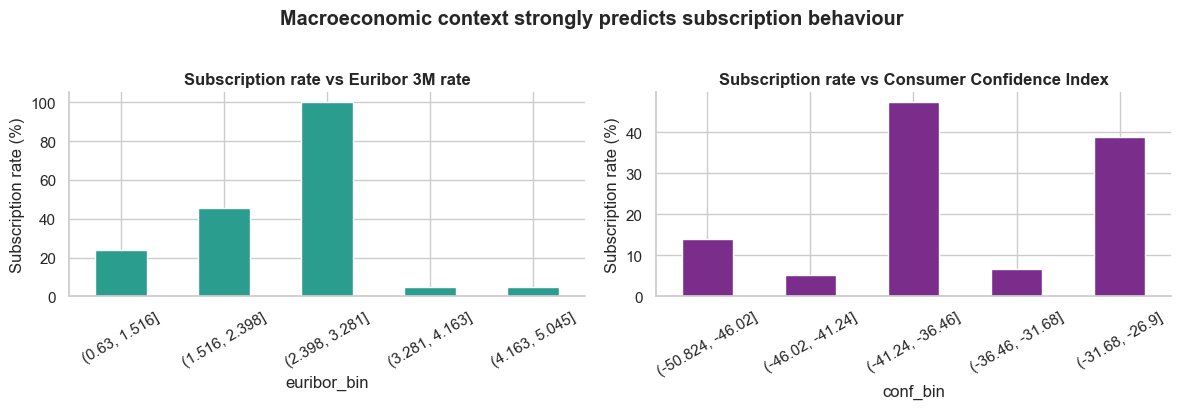

Macro features EDA plot saved.


In [420]:
# --- Plot: Subscription rate vs macroeconomic features ---
df_orig['euribor_bin'] = pd.cut(df_orig['euribor3m'], bins=5)
euribor_rate = df_orig.groupby('euribor_bin', observed=True)['y_enc'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

euribor_rate.plot(kind='bar', ax=axes[0], color=TEAL, edgecolor='white')
axes[0].set_title('Subscription rate vs Euribor 3M rate', fontweight='bold')
axes[0].set_ylabel('Subscription rate (%)')
axes[0].tick_params(axis='x', rotation=30)

df_orig['conf_bin'] = pd.cut(df_orig['cons.conf.idx'], bins=5)
conf_rate = df_orig.groupby('conf_bin', observed=True)['y_enc'].mean() * 100
conf_rate.plot(kind='bar', ax=axes[1], color=PURPLE, edgecolor='white')
axes[1].set_title('Subscription rate vs Consumer Confidence Index', fontweight='bold')
axes[1].set_ylabel('Subscription rate (%)')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Macroeconomic context strongly predicts subscription behaviour',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_macro_features.png', dpi=150, bbox_inches='tight')
plt.show()
print('Macro features EDA plot saved.')

## Section 4 — Model Training

### Model Selection Rationale

**Logistic Regression** was chosen as a linear, interpretable baseline. Its coefficients carry a direct directional interpretation (log-odds), making it easy to explain to a non-technical banking audience and to audit for regulatory compliance.

**Random Forest** was chosen to capture non-linear relationships and feature interactions that logistic regression cannot model. It also produces feature importance scores that translate directly into actionable business recommendations.

**Two models are compared deliberately** to assess the bias-variance tradeoff: if both models agree on key drivers, findings are more robust. Divergence between models signals complexity that warrants further investigation.

In [421]:
# --- 4a: Stratified 80/20 train/test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train size : {X_train.shape[0]:,}')
print(f'Test  size : {X_test.shape[0]:,}')
print('\nTrain class balance:')
print(y_train.value_counts(normalize=True).rename({0: 'No (0)', 1: 'Yes (1)'}).round(4))
print('\nTest class balance:')
print(y_test.value_counts(normalize=True).rename({0: 'No (0)', 1: 'Yes (1)'}).round(4))

Train size : 32,950
Test  size : 8,238

Train class balance:
y_enc
No (0)     0.8873
Yes (1)    0.1127
Name: proportion, dtype: float64

Test class balance:
y_enc
No (0)     0.8874
Yes (1)    0.1126
Name: proportion, dtype: float64


In [422]:
# Run once in a separate cell
!pip install imbalanced-learn


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [423]:
from imblearn.over_sampling import SMOTE

In [424]:
# --- 3b: SMOTE oversampling (training set only) ---
smote = SMOTE(random_state=RANDOM_STATE)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f'Before SMOTE: {pd.Series(y_train).value_counts().to_dict()}')
print(f'After SMOTE:  {pd.Series(y_train_sm).value_counts().to_dict()}')

Before SMOTE: {0: 29238, 1: 3712}
After SMOTE:  {0: 29238, 1: 29238}


In [425]:
# --- 4b: Scale numerical features for Logistic Regression only ---
# Random Forest and XGBoost are scale-invariant; LR is not.
# Scaler is fit ONLY on training data to prevent data leakage.
# euribor_x_financial and warmth_x_wealth restored as debt_burden-based interactions.
num_features = [
    'age', 'previous', 'pdays', 'euribor3m', 'cons.conf.idx',
    'education_ord', 'debt_burden', 'log_campaign',
    'relationship_quality', 'highval_x_euribor',
    'euribor_x_financial', 'warmth_x_wealth'
]
# Keep only those that actually exist in the feature matrix
num_features = [f for f in num_features if f in X_train.columns]

scaler = StandardScaler()
X_train_scaled = X_train_sm.copy()
X_test_scaled  = X_test.copy()
X_train_scaled[num_features] = scaler.fit_transform(X_train_sm[num_features])
X_test_scaled[num_features]  = scaler.transform(X_test[num_features])

print(f'Scaled {len(num_features)} numerical features for Logistic Regression.')
print('Features scaled:', num_features)

Scaled 12 numerical features for Logistic Regression.
Features scaled: ['age', 'previous', 'pdays', 'euribor3m', 'cons.conf.idx', 'education_ord', 'debt_burden', 'log_campaign', 'relationship_quality', 'highval_x_euribor', 'euribor_x_financial', 'warmth_x_wealth']


In [426]:
# Original-scale training data for CV evaluation (pre-SMOTE, unbalanced)
X_train_scaled_orig = X_train.copy()
X_train_scaled_orig[num_features] = scaler.transform(X_train[num_features])

In [427]:
# --- 4c: Logistic Regression baseline ---
lr = LogisticRegression(
    class_weight='balanced', max_iter=1000, random_state=42
)
lr.fit(X_train_scaled, y_train_sm)

y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

print('=== Logistic Regression — Test Set Report ===')
print(classification_report(
    y_test, y_pred_lr,
    target_names=['No Subscription', 'Subscription']
))

=== Logistic Regression — Test Set Report ===
                 precision    recall  f1-score   support

No Subscription       0.92      0.88      0.90      7310
   Subscription       0.31      0.42      0.36       928

       accuracy                           0.83      8238
      macro avg       0.62      0.65      0.63      8238
   weighted avg       0.85      0.83      0.84      8238



In [428]:
# --- 4d: Random Forest main model (unscaled features) ---
rf = RandomForestClassifier(
    n_estimators=100, class_weight='balanced', random_state=42
)
rf.fit(X_train_sm, y_train_sm)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print('=== Random Forest (baseline 100 trees) — Test Set Report ===')
print(classification_report(
    y_test, y_pred_rf,
    target_names=['No Subscription', 'Subscription']
))

=== Random Forest (baseline 100 trees) — Test Set Report ===
                 precision    recall  f1-score   support

No Subscription       0.93      0.94      0.94      7310
   Subscription       0.49      0.42      0.46       928

       accuracy                           0.89      8238
      macro avg       0.71      0.68      0.70      8238
   weighted avg       0.88      0.89      0.88      8238



### Why XGBoost?

Logistic Regression and Random Forest represent two distinct paradigms — linear modelling and parallel bagging. **XGBoost** (Extreme Gradient Boosting) adds a third: *sequential boosting*. Each tree is trained to correct the residual errors of the previous one, making the ensemble increasingly precise on hard-to-classify cases.

Crucially, XGBoost includes a native `scale_pos_weight` parameter designed specifically for class imbalance, setting the weight of positive examples relative to negatives. This is set to `(y_train == 0).sum() / (y_train == 1).sum()` ≈ 4.7, matching the empirical class ratio in the training data — no need to resample or apply post-hoc corrections.

After SMOTE balances the training classes, scale_pos_weight resolves to 1.0 — class weighting is handled by the resampling rather than the parameter.

In [429]:
# Define cv here so tuning cells below can reference it
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# --- XGBoost: compute class imbalance ratio ---
neg = (y_train_sm == 0).sum()
pos = (y_train_sm == 1).sum()
spw = neg / pos
print(f'scale_pos_weight = {neg}/{pos} = {spw:.2f}')

# --- Baseline XGBoost ---
xgb = XGBClassifier(
    scale_pos_weight=spw,
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train_sm, y_train_sm)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

print('\n=== XGBoost (baseline) — Test Set Report ===')
print(classification_report(
    y_test, y_pred_xgb,
    target_names=['No Subscription', 'Subscription']
))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_xgb):.4f}')

scale_pos_weight = 29238/29238 = 1.00

=== XGBoost (baseline) — Test Set Report ===
                 precision    recall  f1-score   support

No Subscription       0.93      0.94      0.94      7310
   Subscription       0.50      0.45      0.47       928

       accuracy                           0.89      8238
      macro avg       0.71      0.69      0.70      8238
   weighted avg       0.88      0.89      0.88      8238

ROC-AUC: 0.7887


In [430]:
# --- 4e: Hyperparameter tuning via GridSearchCV ---
param_grid = {
    'n_estimators':    [100, 200],
    'max_depth':       [None, 10, 20],
    'min_samples_split': [2, 5]
}
cv_strat = StratifiedKFold(n_splits=5)

grid_search = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid=param_grid,
    cv=cv_strat,
    scoring='f1',
    n_jobs=-1,
    verbose=0
)
grid_search.fit(X_train_sm, y_train_sm)

print('Best parameters :', grid_search.best_params_)
print(f'Best CV F1 (weighted): {grid_search.best_score_:.4f}')

rf_best = grid_search.best_estimator_
y_pred_rf_best = rf_best.predict(X_test)
y_prob_rf_best = rf_best.predict_proba(X_test)[:, 1]

print('\n=== Random Forest (tuned) — Test Set Report ===')
print(classification_report(
    y_test, y_pred_rf_best,
    target_names=['No Subscription', 'Subscription']
))

Best parameters : {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Best CV F1 (weighted): 0.9216

=== Random Forest (tuned) — Test Set Report ===
                 precision    recall  f1-score   support

No Subscription       0.93      0.94      0.94      7310
   Subscription       0.49      0.42      0.46       928

       accuracy                           0.89      8238
      macro avg       0.71      0.68      0.70      8238
   weighted avg       0.88      0.89      0.88      8238



In [431]:
# --- 4e-LR: Hyperparameter tuning for Logistic Regression ---
lr_param_grid = {'C': [0.01, 0.1, 1, 10, 100]}
_cv_lr_tune = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

lr_grid = GridSearchCV(
    LogisticRegression(class_weight='balanced', solver='liblinear', random_state=RANDOM_STATE),
    lr_param_grid,
    cv=_cv_lr_tune,
    scoring='f1',
    n_jobs=-1
)
lr_grid.fit(X_train_scaled, y_train_sm)

print(f'Best LR C: {lr_grid.best_params_}')
print(f'Best LR CV F1 (weighted): {lr_grid.best_score_:.4f}')

lr_best = lr_grid.best_estimator_

# Update predictions so all downstream evaluation uses the tuned model
y_pred_lr = lr_best.predict(X_test_scaled)
y_prob_lr = lr_best.predict_proba(X_test_scaled)[:, 1]

print('\n=== Logistic Regression (tuned) — Test Set Report ===')
print(classification_report(
    y_test, y_pred_lr,
    target_names=['No Subscription', 'Subscription']
))

Best LR C: {'C': 10}
Best LR CV F1 (weighted): 0.8570

=== Logistic Regression (tuned) — Test Set Report ===
                 precision    recall  f1-score   support

No Subscription       0.92      0.88      0.90      7310
   Subscription       0.31      0.42      0.36       928

       accuracy                           0.83      8238
      macro avg       0.62      0.65      0.63      8238
   weighted avg       0.85      0.83      0.84      8238



In [432]:
# --- XGBoost: Hyperparameter tuning via GridSearchCV ---
xgb_param_grid = {
    'n_estimators':  [100, 200],
    'max_depth':     [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample':     [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    XGBClassifier(
        scale_pos_weight=spw,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ),
    xgb_param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=0
)
xgb_grid.fit(X_train_sm, y_train_sm)

print(f'Best XGBoost parameters: {xgb_grid.best_params_}')
print(f'Best CV F1:   {xgb_grid.best_score_:.4f}')

xgb_best        = xgb_grid.best_estimator_
y_pred_xgb_best = xgb_best.predict(X_test)
y_prob_xgb_best = xgb_best.predict_proba(X_test)[:, 1]

print('\n=== XGBoost (tuned) — Test Set Report ===')
print(classification_report(
    y_test, y_pred_xgb_best,
    target_names=['No Subscription', 'Subscription']
))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_xgb_best):.4f}')

Best XGBoost parameters: {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 200, 'subsample': 1.0}
Best CV F1:   0.9318

=== XGBoost (tuned) — Test Set Report ===
                 precision    recall  f1-score   support

No Subscription       0.92      0.96      0.94      7310
   Subscription       0.53      0.38      0.44       928

       accuracy                           0.89      8238
      macro avg       0.73      0.67      0.69      8238
   weighted avg       0.88      0.89      0.88      8238

ROC-AUC: 0.7776


In [433]:
# --- CatBoost: install and import ---
import subprocess
subprocess.run(['pip', 'install', 'catboost', '--quiet'], check=True)
from catboost import CatBoostClassifier
print('CatBoost ready.')

CatBoost ready.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [434]:
# --- CatBoost: build unencoded feature matrix X_cat ---
# CatBoost handles categorical columns natively — pass raw string categories.
# Categorical engineered features were saved before one-hot encoding (above).

cat_features_list = [
    'job', 'marital', 'contact', 'month',
    'day_of_week', 'poutcome',
    'age_group', 'contact_recency',
    'job_stability', 'age_job_segment'
]

X_cat_df = df_orig[[
    'age', 'job', 'marital', 'contact', 'month', 'day_of_week',
    'pdays', 'previous', 'poutcome', 'euribor3m', 'cons.conf.idx'
]].copy()

# Binary columns as numeric
for col in ['default', 'housing', 'loan']:
    X_cat_df[col] = (df_orig[col] == 'yes').astype(int)

# Add numeric engineered features
for feat in ['education_ord', 'has_been_contacted', 'debt_burden', 'log_campaign',
             'relationship_quality', 'high_value_segment', 'highval_x_euribor',
             'euribor_x_financial', 'warmth_x_wealth']:
    X_cat_df[feat] = df[feat]

# Add categorical engineered features (saved before encoding)
for feat, series in _saved_cat_feats_for_catboost.items():
    X_cat_df[feat] = series.values

X_cat = X_cat_df.copy()
print('X_cat shape:', X_cat.shape)
print('Categorical features for CatBoost:', cat_features_list)

X_cat_train = X_cat.loc[X_train.index]
X_cat_test  = X_cat.loc[X_test.index]
print('X_cat_train:', X_cat_train.shape, '  X_cat_test:', X_cat_test.shape)

X_cat shape: (41188, 27)
Categorical features for CatBoost: ['job', 'marital', 'contact', 'month', 'day_of_week', 'poutcome', 'age_group', 'contact_recency', 'job_stability', 'age_job_segment']
X_cat_train: (32950, 27)   X_cat_test: (8238, 27)


In [435]:
# --- CatBoost: baseline model ---
cat = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    scale_pos_weight=spw,
    eval_metric='F1',
    cat_features=cat_features_list,
    random_seed=42,
    verbose=0
)
cat.fit(X_cat_train, y_train)

y_pred_cat = cat.predict(X_cat_test)
y_prob_cat = cat.predict_proba(X_cat_test)[:, 1]

print('=== CatBoost (baseline) — Test Set Report ===')
print(classification_report(y_test, y_pred_cat,
      target_names=['No Subscription', 'Subscription']))

=== CatBoost (baseline) — Test Set Report ===
                 precision    recall  f1-score   support

No Subscription       0.91      0.98      0.95      7310
   Subscription       0.67      0.27      0.39       928

       accuracy                           0.90      8238
      macro avg       0.79      0.63      0.67      8238
   weighted avg       0.89      0.90      0.88      8238



In [436]:
# --- CatBoost: Hyperparameter tuning via GridSearchCV (reduced grid) ---
# Reduced to 8 combinations × 5 folds = 40 fits (≈10-15 min).
# iterations fixed at 300; early_stopping_rounds=50 cuts further if score plateaus.
cat_param_grid = {
    'learning_rate': [0.05, 0.1],
    'depth':         [4, 6],
    'l2_leaf_reg':   [1, 3]
}

_cv_cat = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cat_grid = GridSearchCV(
    CatBoostClassifier(
        iterations=300,
        early_stopping_rounds=50,
        scale_pos_weight=spw,
        eval_metric='F1',
        cat_features=cat_features_list,
        random_seed=42,
        verbose=0
    ),
    cat_param_grid,
    cv=_cv_cat,
    scoring='f1',
    n_jobs=-1
)
cat_grid.fit(X_cat_train, y_train)
cat_best = cat_grid.best_estimator_

y_pred_cat_best = cat_best.predict(X_cat_test)
y_prob_cat_best = cat_best.predict_proba(X_cat_test)[:, 1]

print(f'Best CatBoost params: {cat_grid.best_params_}')
print(f'Best CV F1:           {cat_grid.best_score_:.4f}')
print('\n=== CatBoost (tuned) — Test Set Report ===')
print(classification_report(y_test, y_pred_cat_best,
      target_names=['No Subscription', 'Subscription']))

Best CatBoost params: {'depth': 6, 'l2_leaf_reg': 3, 'learning_rate': 0.1}
Best CV F1:           0.3715

=== CatBoost (tuned) — Test Set Report ===
                 precision    recall  f1-score   support

No Subscription       0.91      0.98      0.95      7310
   Subscription       0.67      0.27      0.38       928

       accuracy                           0.90      8238
      macro avg       0.79      0.62      0.66      8238
   weighted avg       0.89      0.90      0.88      8238



In [437]:
# --- 4f: 5-Fold Cross-Validation for all models ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['f1', 'roc_auc', 'precision', 'recall',
            'f1_weighted', 'precision_weighted', 'recall_weighted']

cv_lr_results  = cross_validate(lr_best,    X_train_scaled_orig, y_train, cv=cv, scoring=scoring)
cv_rf_results  = cross_validate(rf_best,    X_train,        y_train, cv=cv, scoring=scoring)
cv_xg_results  = cross_validate(xgb_best,   X_train,        y_train, cv=cv, scoring=scoring)
cv_cat_results = cross_validate(cat_best,   X_cat_train,    y_train, cv=cv, scoring=scoring)

metric_labels = {'f1': 'F1', 'roc_auc': 'ROC-AUC', 'precision': 'Precision', 'recall': 'Recall'}

print(f'{"Metric":<28} {"LR Mean":>10} {"LR Std":>8} {"RF Mean":>10} {"RF Std":>8}'
      f' {"XGB Mean":>10} {"XGB Std":>8} {"CAT Mean":>10} {"CAT Std":>8}')
print('-' * 110)
for metric, label in metric_labels.items():
    key = f'test_{metric}'
    lr_m  = cv_lr_results[key].mean();  lr_s  = cv_lr_results[key].std()
    rf_m  = cv_rf_results[key].mean();  rf_s  = cv_rf_results[key].std()
    xg_m  = cv_xg_results[key].mean();  xg_s  = cv_xg_results[key].std()
    ca_m  = cv_cat_results[key].mean(); ca_s  = cv_cat_results[key].std()
    print(f'{label:<28} {lr_m:>10.4f} {lr_s:>8.4f} {rf_m:>10.4f} {rf_s:>8.4f}'
          f' {xg_m:>10.4f} {xg_s:>8.4f} {ca_m:>10.4f} {ca_s:>8.4f}')

Metric                          LR Mean   LR Std    RF Mean   RF Std   XGB Mean  XGB Std   CAT Mean  CAT Std
--------------------------------------------------------------------------------------------------------------
F1                               0.4346   0.0050     0.3387   0.0108     0.3719   0.0088     0.3715   0.0114
ROC-AUC                          0.7856   0.0052     0.7694   0.0065     0.7718   0.0081     0.7979   0.0029
Precision                        0.3308   0.0057     0.5471   0.0193     0.5677   0.0207     0.6417   0.0177
Recall                           0.6334   0.0028     0.2457   0.0121     0.2767   0.0077     0.2616   0.0105


In [438]:
# --- 4g: class_weight='balanced' variant comparison ---
# Run balanced variants through CV alongside the main models to confirm
# that balanced class weighting improves minority-class recall.
lr_balanced = LogisticRegression(
    solver='liblinear', C=1.0,
    class_weight='balanced',
    random_state=RANDOM_STATE
)
rf_balanced = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=RANDOM_STATE
)

lr_bal_cv = cross_validate(lr_balanced, X_train_scaled_orig, y_train, cv=cv, scoring=scoring)
rf_bal_cv = cross_validate(rf_balanced, X_train,     y_train, cv=cv, scoring=scoring)

print('Cross-validation — balanced class_weight variants (mean across 5 folds):')
print(f'{"Metric":<28} {"LR Balanced":>14} {"RF Balanced":>14}')
print('-' * 58)
for metric, label in metric_labels.items():
    key = f'test_{metric}'
    lb_m = lr_bal_cv[key].mean()
    rb_m = rf_bal_cv[key].mean()
    print(f'{label:<28} {lb_m:>14.4f} {rb_m:>14.4f}')

Cross-validation — balanced class_weight variants (mean across 5 folds):
Metric                          LR Balanced    RF Balanced
----------------------------------------------------------
F1                                   0.4346         0.3387
ROC-AUC                              0.7856         0.7694
Precision                            0.3308         0.5471
Recall                               0.6334         0.2457


**Why `class_weight='balanced'`?** In this dataset, ~82% of observations belong to the negative class (no subscription). Without adjustment, a classifier trained on raw counts will optimise for the majority class and largely ignore the minority. Setting `class_weight='balanced'` instructs the algorithm to weight each observation inversely proportional to its class frequency — effectively penalising misclassification of the rare positive class (subscription) more heavily. This is operationally justified: the cost of *missing* a genuine subscriber (a lost revenue opportunity) typically exceeds the cost of a *wasted call* to a non-subscriber (a small cost-per-contact). Using balanced weights re-aligns the model's loss function with the bank's actual cost asymmetry.

## Section 5 — Evaluation

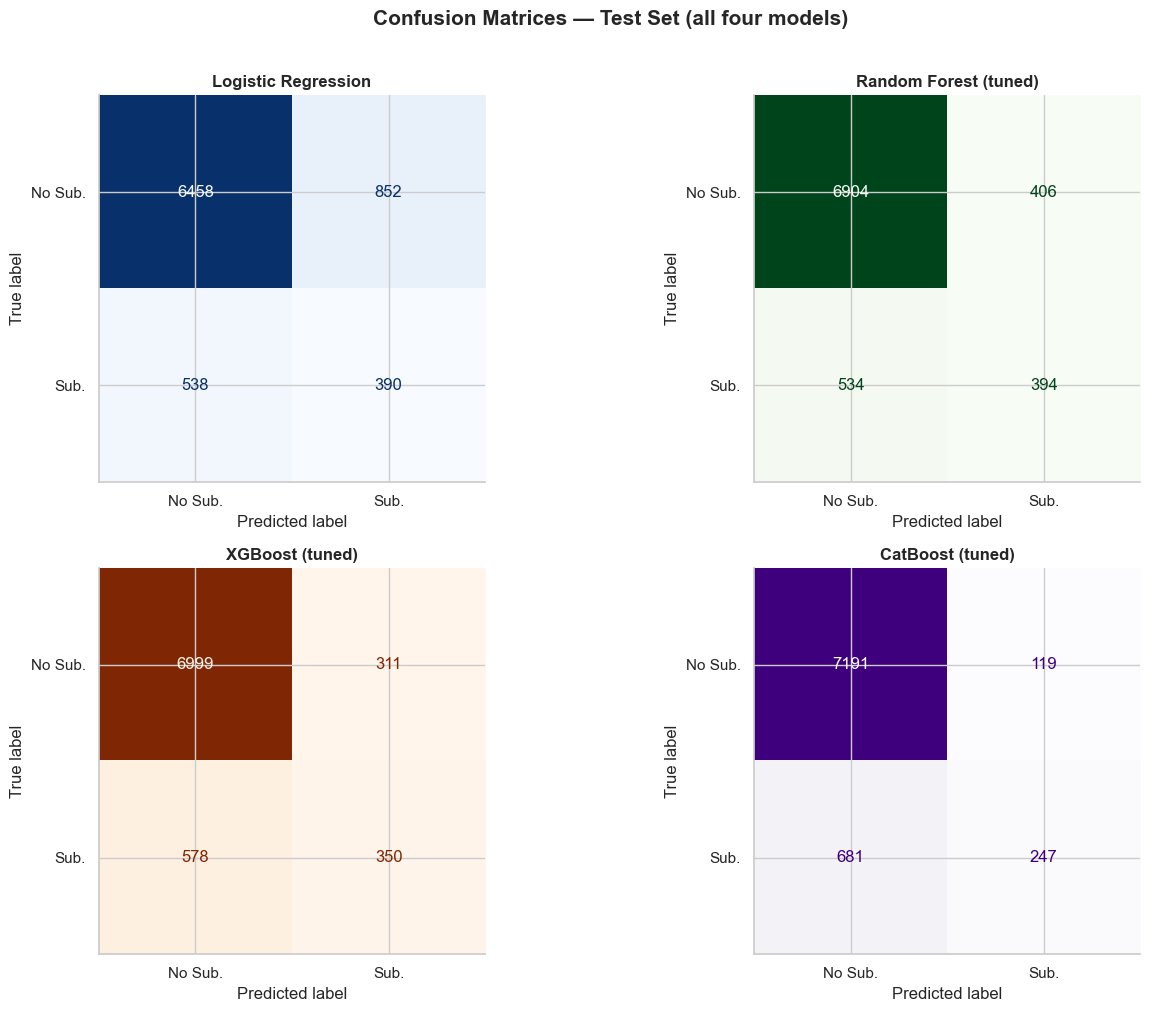

Plot 7 saved.


In [439]:
# --- Plot 7: Confusion matrices (2×2) — all four models ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

cm_configs = [
    (y_pred_lr,       'Logistic Regression',   'Blues',   axes[0, 0]),
    (y_pred_rf_best,  'Random Forest (tuned)',  'Greens',  axes[0, 1]),
    (y_pred_xgb_best, 'XGBoost (tuned)',        'Oranges', axes[1, 0]),
    (y_pred_cat_best, 'CatBoost (tuned)',        'Purples', axes[1, 1]),
]

for preds, title, cmap, ax in cm_configs:
    ConfusionMatrixDisplay.from_predictions(
        y_test, preds,
        display_labels=['No Sub.', 'Sub.'],
        ax=ax, colorbar=False, cmap=cmap
    )
    ax.set_title(title, fontsize=12, fontweight='bold')

plt.suptitle('Confusion Matrices — Test Set (all four models)',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot7_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot 7 saved.')

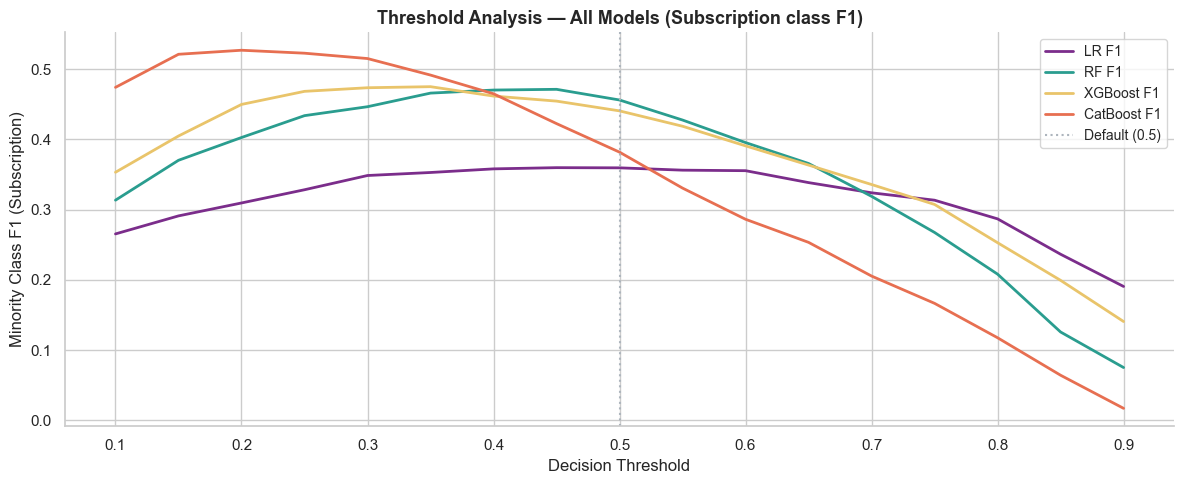


LR        : optimal threshold = 0.45,  best minority F1 = 0.3597
RF        : optimal threshold = 0.45,  best minority F1 = 0.4712
XGBoost   : optimal threshold = 0.35,  best minority F1 = 0.4750
CatBoost  : optimal threshold = 0.20,  best minority F1 = 0.5269

Note: cost-sensitive optimal thresholds are computed in Section 6.
Plot saved: plot_threshold_comparison.png


In [440]:
# --- Threshold sweep: all four models — minority class Precision / Recall / F1 ---
thresholds = np.arange(0.1, 0.91, 0.05)

sweep_models = [
    ('LR',       y_prob_lr,        PURPLE),
    ('RF',       y_prob_rf_best,   TEAL),
    ('XGBoost',  y_prob_xgb_best,  AMBER),
    ('CatBoost', y_prob_cat_best,  CORAL),
]

sweep_results = {}
for label, prob, _ in sweep_models:
    vals = []
    for t in thresholds:
        preds_t = (prob >= t).astype(int)
        p, r, f, _ = precision_recall_fscore_support(
            y_test, preds_t, labels=[1], average='binary', zero_division=0
        )
        vals.append((p, r, f))
    sweep_results[label] = vals

fig, ax = plt.subplots(figsize=(12, 5))
for label, _, colour in sweep_models:
    f1s = [x[2] for x in sweep_results[label]]
    ax.plot(thresholds, f1s, label=f'{label} F1', color=colour, linewidth=2)

ax.axvline(0.5, color=GRAY, linestyle=':', linewidth=1.5, label='Default (0.5)')
ax.set_xlabel('Decision Threshold', fontsize=12)
ax.set_ylabel('Minority Class F1 (Subscription)', fontsize=12)
ax.set_title(
    'Threshold Analysis — All Models (Subscription class F1)',
    fontweight='bold', fontsize=13
)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('plot_threshold_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'{""}')  # spacer
for label, _, _ in sweep_models:
    f1s = [x[2] for x in sweep_results[label]]
    best_t = thresholds[int(np.argmax(f1s))]
    print(f'{label:<10}: optimal threshold = {best_t:.2f},  '
          f'best minority F1 = {max(f1s):.4f}')
print('\nNote: cost-sensitive optimal thresholds are computed in Section 6.')
print('Plot saved: plot_threshold_comparison.png')

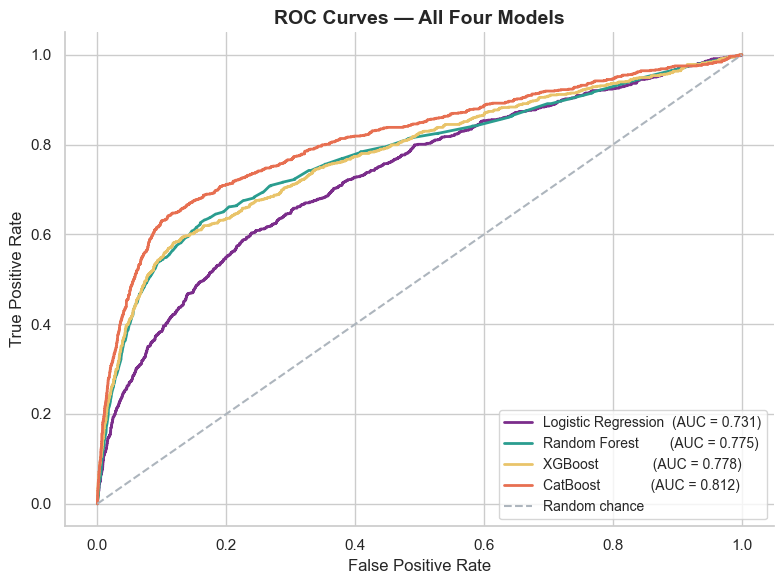

Plot 8 saved.


In [441]:
# --- Plot 8: ROC curves — all four models ---
fpr_lr,  tpr_lr,  _ = roc_curve(y_test, y_prob_lr)
fpr_rf,  tpr_rf,  _ = roc_curve(y_test, y_prob_rf_best)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb_best)
fpr_cat, tpr_cat, _ = roc_curve(y_test, y_prob_cat_best)

auc_lr  = roc_auc_score(y_test, y_prob_lr)
auc_rf  = roc_auc_score(y_test, y_prob_rf_best)
auc_xgb = roc_auc_score(y_test, y_prob_xgb_best)
auc_cat = roc_auc_score(y_test, y_prob_cat_best)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr_lr,  tpr_lr,  color=PURPLE, linewidth=2,
        label=f'Logistic Regression  (AUC = {auc_lr:.3f})')
ax.plot(fpr_rf,  tpr_rf,  color=TEAL,   linewidth=2,
        label=f'Random Forest        (AUC = {auc_rf:.3f})')
ax.plot(fpr_xgb, tpr_xgb, color=AMBER,  linewidth=2,
        label=f'XGBoost              (AUC = {auc_xgb:.3f})')
ax.plot(fpr_cat, tpr_cat, color=CORAL,  linewidth=2,
        label=f'CatBoost             (AUC = {auc_cat:.3f})')
ax.plot([0, 1], [0, 1], color=GRAY, linestyle='--',
        linewidth=1.5, label='Random chance')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — All Four Models', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('plot8_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot 8 saved.')

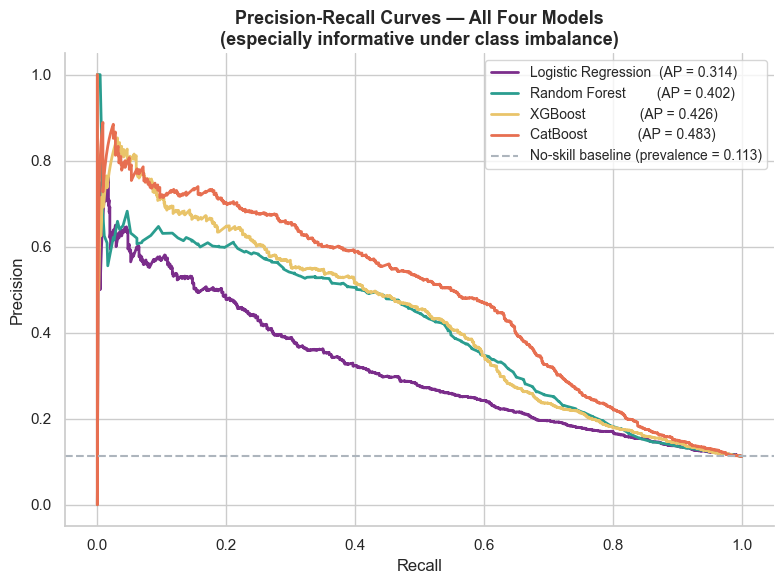

Plot 9 saved.


In [442]:
# --- Plot 9: Precision-Recall curves — all four models ---
prec_lr_c,  rec_lr_c,  _ = precision_recall_curve(y_test, y_prob_lr)
prec_rf_c,  rec_rf_c,  _ = precision_recall_curve(y_test, y_prob_rf_best)
prec_xgb_c, rec_xgb_c, _ = precision_recall_curve(y_test, y_prob_xgb_best)
prec_cat_c, rec_cat_c, _ = precision_recall_curve(y_test, y_prob_cat_best)

ap_lr_p  = average_precision_score(y_test, y_prob_lr)
ap_rf_p  = average_precision_score(y_test, y_prob_rf_best)
ap_xgb_p = average_precision_score(y_test, y_prob_xgb_best)
ap_cat_p = average_precision_score(y_test, y_prob_cat_best)
baseline_pr = y_test.mean()

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(rec_lr_c,  prec_lr_c,  color=PURPLE, linewidth=2,
        label=f'Logistic Regression  (AP = {ap_lr_p:.3f})')
ax.plot(rec_rf_c,  prec_rf_c,  color=TEAL,   linewidth=2,
        label=f'Random Forest        (AP = {ap_rf_p:.3f})')
ax.plot(rec_xgb_c, prec_xgb_c, color=AMBER,  linewidth=2,
        label=f'XGBoost              (AP = {ap_xgb_p:.3f})')
ax.plot(rec_cat_c, prec_cat_c, color=CORAL,  linewidth=2,
        label=f'CatBoost             (AP = {ap_cat_p:.3f})')
ax.axhline(y=baseline_pr, color=GRAY, linestyle='--', linewidth=1.5,
           label=f'No-skill baseline (prevalence = {baseline_pr:.3f})')

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title(
    'Precision-Recall Curves — All Four Models\n'
    '(especially informative under class imbalance)',
    fontsize=13, fontweight='bold'
)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('plot9_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot 9 saved.')

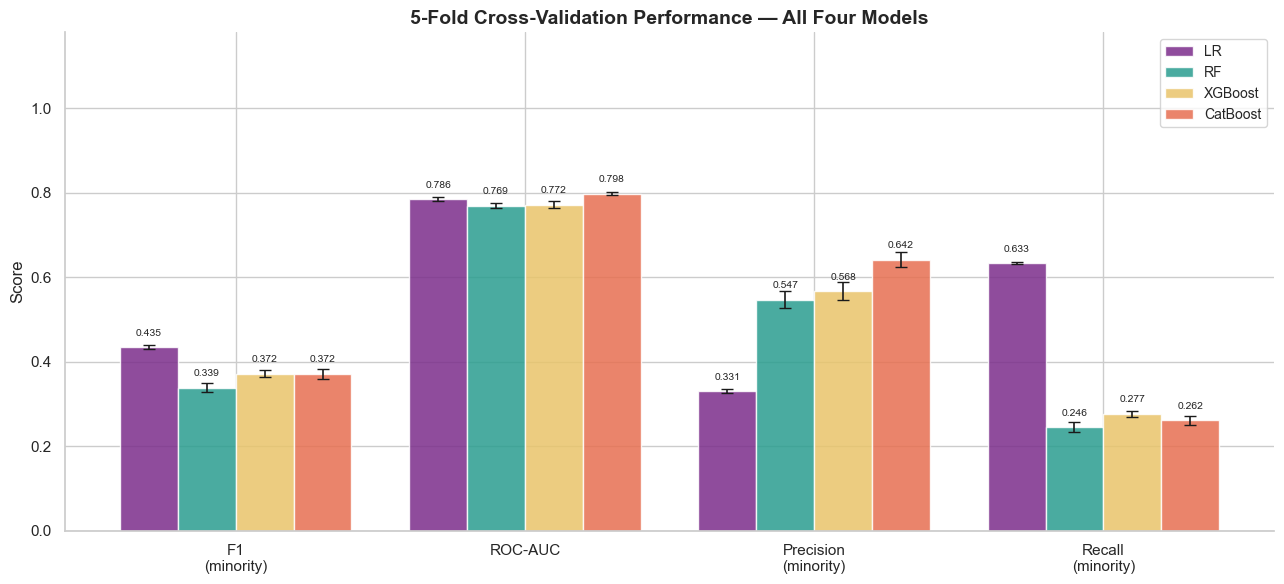

Plot 10 saved.


In [443]:
# --- Plot 10: Cross-validation comparison bar chart — all four models ---
metrics_list   = ['f1', 'roc_auc', 'precision', 'recall']
metric_display = ['F1\n(minority)', 'ROC-AUC', 'Precision\n(minority)', 'Recall\n(minority)']

cv_data = [
    ('LR',       cv_lr_results,  PURPLE),
    ('RF',       cv_rf_results,  TEAL),
    ('XGBoost',  cv_xg_results,  AMBER),
    ('CatBoost', cv_cat_results, CORAL),
]

n_metrics = len(metrics_list)
n_models  = len(cv_data)
width     = 0.2
x         = np.arange(n_metrics)
offsets   = np.linspace(-(n_models - 1) / 2, (n_models - 1) / 2, n_models) * width

fig, ax = plt.subplots(figsize=(13, 6))

for (name, results, colour), offset in zip(cv_data, offsets):
    means = [results[f'test_{m}'].mean() for m in metrics_list]
    stds  = [results[f'test_{m}'].std()  for m in metrics_list]
    bars  = ax.bar(x + offset, means, width, yerr=stds, capsize=4,
                   color=colour, alpha=0.85, label=name,
                   error_kw={'linewidth': 1.2})
    for bar, h in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.022,
                f'{h:.3f}', ha='center', va='bottom', fontsize=7.5)

ax.set_xticks(x)
ax.set_xticklabels(metric_display, fontsize=11)
ax.set_ylim(0, 1.18)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('5-Fold Cross-Validation Performance — All Four Models',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('plot10_cv_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot 10 saved.')

In [444]:
# --- Four-model summary table: overall + minority class metrics ---
report_lr  = classification_report(y_test, y_pred_lr,       output_dict=True)
report_rf  = classification_report(y_test, y_pred_rf_best,  output_dict=True)
report_xgb = classification_report(y_test, y_pred_xgb_best, output_dict=True)
report_cat = classification_report(y_test, y_pred_cat_best, output_dict=True)

ap_lr  = average_precision_score(y_test, y_prob_lr)
ap_rf  = average_precision_score(y_test, y_prob_rf_best)
ap_xgb = average_precision_score(y_test, y_prob_xgb_best)
ap_cat = average_precision_score(y_test, y_prob_cat_best)

# Store for final summary cell
f1_lr_test   = report_lr['weighted avg']['f1-score']
roc_lr_test  = roc_auc_score(y_test, y_prob_lr)
f1_rf_test   = report_rf['weighted avg']['f1-score']
roc_rf_test  = roc_auc_score(y_test, y_prob_rf_best)
f1_xgb_test  = report_xgb['weighted avg']['f1-score']
roc_xgb_test = roc_auc_score(y_test, y_prob_xgb_best)
f1_cat_test  = report_cat['weighted avg']['f1-score']
roc_cat_test = roc_auc_score(y_test, y_prob_cat_best)

W = 105
print('=' * W)
print(f'{"Metric":<35} {"Log. Reg.":>12} {"Rand. Forest":>14} {"XGBoost":>10} {"CatBoost":>10}')
print('-' * W)
def row(label, lr, rf, xg, ca):
    print(f'{label:<35} {lr:>12.4f} {rf:>14.4f} {xg:>10.4f} {ca:>10.4f}')
row('F1 weighted',
    report_lr['weighted avg']['f1-score'], report_rf['weighted avg']['f1-score'],
    report_xgb['weighted avg']['f1-score'], report_cat['weighted avg']['f1-score'])
row('ROC-AUC',
    roc_auc_score(y_test, y_prob_lr), roc_auc_score(y_test, y_prob_rf_best),
    roc_auc_score(y_test, y_prob_xgb_best), roc_auc_score(y_test, y_prob_cat_best))
row('Average Precision (PR-AUC)', ap_lr, ap_rf, ap_xgb, ap_cat)
print(f'{"--- Minority class (Subscription) ---"}')
row('  Precision',
    report_lr['1']['precision'], report_rf['1']['precision'],
    report_xgb['1']['precision'], report_cat['1']['precision'])
row('  Recall',
    report_lr['1']['recall'], report_rf['1']['recall'],
    report_xgb['1']['recall'], report_cat['1']['recall'])
row('  F1',
    report_lr['1']['f1-score'], report_rf['1']['f1-score'],
    report_xgb['1']['f1-score'], report_cat['1']['f1-score'])
print('=' * W)
print('\nNote: Weighted F1 is dominated by the majority class (No Subscription, ~89%).')
print('Minority class metrics above reflect true model performance on subscribers.')

Metric                                 Log. Reg.   Rand. Forest    XGBoost   CatBoost
---------------------------------------------------------------------------------------------------------
F1 weighted                               0.8416         0.8822     0.8840     0.8836
ROC-AUC                                   0.7308         0.7752     0.7776     0.8120
Average Precision (PR-AUC)                0.3145         0.4020     0.4258     0.4834
--- Minority class (Subscription) ---
  Precision                               0.3140         0.4925     0.5295     0.6749
  Recall                                  0.4203         0.4246     0.3772     0.2662
  F1                                      0.3594         0.4560     0.4405     0.3818

Note: Weighted F1 is dominated by the majority class (No Subscription, ~89%).
Minority class metrics above reflect true model performance on subscribers.


## Section 6 — Cost-Sensitive Threshold Optimisation

### Business rationale

Every call placed costs the bank a fixed amount regardless of outcome.
Every subscription generates a fixed net margin. The **optimal decision threshold**
is therefore not the statistical default of 0.5, nor even the F1-maximising point —
it is the threshold that **maximises total net campaign value**, defined as
subscription revenue minus total calling costs.

### Formula

$$\text{Net Value} = TP \times \text{sub\_margin} - (TP + FP) \times \text{call\_cost}$$

Which simplifies to:

$$\text{Net Value} = TP \times (\text{sub\_margin} - \text{call\_cost}) - FP \times \text{call\_cost}$$

**Breakeven condition:** the model is profitable at a given threshold whenever
$$\text{Precision} > \frac{\text{call\_cost}}{\text{sub\_margin}}$$

With €5 calls and €100 margin, the breakeven precision is just **5%**. This means
a *low* threshold (high recall, moderate precision) is the economically rational
operating strategy — the bank should cast a wide net and can absorb many false
positives as long as precision stays above 5%.

In [445]:
# --- Section 6: Cost parameters ---
# Replace with the bank's actual figures for production use.
call_cost   = 5     # € cost per outbound call (fixed, regardless of outcome)
sub_margin  = 100   # € net margin per successful term deposit subscription

breakeven_precision = call_cost / sub_margin
print(f'Call cost:            €{call_cost}')
print(f'Subscription margin:  €{sub_margin}')
print(f'Breakeven precision:  {breakeven_precision:.1%}  '
      f'(model is profitable above this precision at any threshold)')

Call cost:            €5
Subscription margin:  €100
Breakeven precision:  5.0%  (model is profitable above this precision at any threshold)


In [446]:
# --- Threshold sweep: net campaign value for all four models ---
thresholds_cs = np.arange(0.01, 1.00, 0.01)

models_cs = {
    'Logistic Regression': y_prob_lr,
    'Random Forest':        y_prob_rf_best,
    'XGBoost':              y_prob_xgb_best,
    'CatBoost':             y_prob_cat_best,
}

net_values   = {}   # {model_name: [net_value_at_each_threshold]}
optimal_info = {}   # {model_name: (opt_threshold, opt_net_value)}

for name, probs in models_cs.items():
    vals = []
    for t in thresholds_cs:
        preds_t = (probs >= t).astype(int)
        tp = int(((preds_t == 1) & (y_test == 1)).sum())
        fp = int(((preds_t == 1) & (y_test == 0)).sum())
        net = tp * sub_margin - (tp + fp) * call_cost
        vals.append(net)
    net_values[name] = vals
    best_idx = int(np.argmax(vals))
    optimal_info[name] = (thresholds_cs[best_idx], vals[best_idx])

print('Threshold sweep complete.')
for name, (t, v) in optimal_info.items():
    print(f'  {name:<22}: optimal threshold = {t:.2f},  net value = €{v:,.0f}')

Threshold sweep complete.
  Logistic Regression   : optimal threshold = 0.05,  net value = €53,010
  Random Forest         : optimal threshold = 0.10,  net value = €54,075
  XGBoost               : optimal threshold = 0.04,  net value = €54,700
  CatBoost              : optimal threshold = 0.06,  net value = €57,255


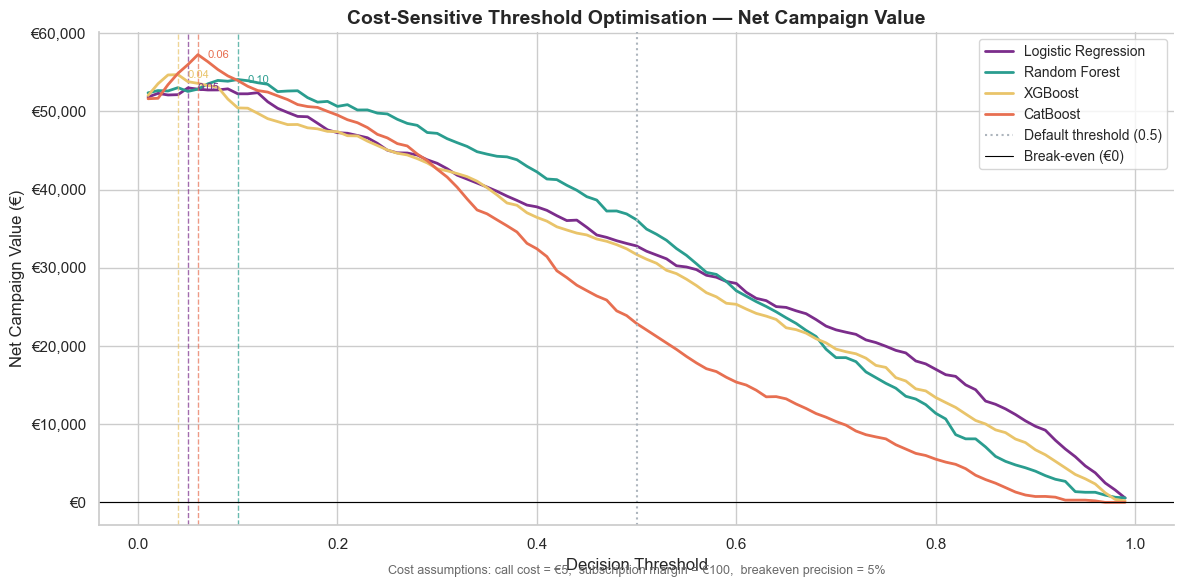

Plot saved: plot_cost_threshold.png


In [447]:
# --- Plot: Net campaign value vs threshold for all four models ---
model_colors = {
    'Logistic Regression': PURPLE,
    'Random Forest':        TEAL,
    'XGBoost':              AMBER,
    'CatBoost':             CORAL,
}

fig, ax = plt.subplots(figsize=(12, 6))

for name, vals in net_values.items():
    colour = model_colors[name]
    opt_t, opt_v = optimal_info[name]
    ax.plot(thresholds_cs, vals, color=colour, linewidth=2, label=name)
    ax.axvline(opt_t, color=colour, linestyle='--', linewidth=1.0, alpha=0.7)
    ax.annotate(f'{opt_t:.2f}', xy=(opt_t, opt_v),
                xytext=(opt_t + 0.01, opt_v),
                fontsize=8, color=colour, va='center')

ax.axvline(0.5, color=GRAY, linestyle=':', linewidth=1.5, label='Default threshold (0.5)')
ax.axhline(0, color='black', linestyle='-', linewidth=0.8, label='Break-even (€0)')

ax.set_xlabel('Decision Threshold', fontsize=12)
ax.set_ylabel('Net Campaign Value (€)', fontsize=12)
ax.set_title(
    'Cost-Sensitive Threshold Optimisation — Net Campaign Value',
    fontsize=14, fontweight='bold'
)
ax.set_subtitle = None  # matplotlib compat
ax.text(0.5, -0.10,
        f'Cost assumptions: call cost = €{call_cost},  subscription margin = €{sub_margin},'
        f'  breakeven precision = {breakeven_precision:.0%}',
        transform=ax.transAxes, ha='center', fontsize=9, color='dimgray')
ax.legend(fontsize=10, loc='upper right')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'€{x:,.0f}'))
plt.tight_layout()
plt.savefig('plot_cost_threshold.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved: plot_cost_threshold.png')

In [448]:
# --- Optimal threshold summary: uplift vs default 0.5 threshold ---
print('=' * 80)
print(f'{"Model":<22} {"Opt. Thresh":>12} {"Net @ Opt (€)":>15}'
      f' {"Net @ 0.5 (€)":>15} {"Uplift (€)":>12}')
print('-' * 80)

best_model_name  = None
best_model_value = -float('inf')
best_model_thresh = None

for name, probs in models_cs.items():
    opt_t, opt_v = optimal_info[name]

    # Net value at default 0.5
    preds_05 = (probs >= 0.5).astype(int)
    tp_05 = int(((preds_05 == 1) & (y_test == 1)).sum())
    fp_05 = int(((preds_05 == 1) & (y_test == 0)).sum())
    net_05 = tp_05 * sub_margin - (tp_05 + fp_05) * call_cost

    uplift = opt_v - net_05
    print(f'{name:<22} {opt_t:>12.2f} {opt_v:>15,.0f} {net_05:>15,.0f} {uplift:>12,.0f}')

    if opt_v > best_model_value:
        best_model_value  = opt_v
        best_model_name   = name
        best_model_thresh = opt_t
        best_model_probs  = probs

print('=' * 80)
print(f'\nBest model: {best_model_name}  |  Optimal threshold: {best_model_thresh:.2f}'
      f'  |  Net value: €{best_model_value:,.0f}')

Model                   Opt. Thresh   Net @ Opt (€)   Net @ 0.5 (€)   Uplift (€)
--------------------------------------------------------------------------------
Logistic Regression            0.05          53,010          32,790       20,220
Random Forest                  0.10          54,075          36,135       17,940
XGBoost                        0.04          54,700          31,695       23,005
CatBoost                       0.06          57,255          22,870       34,385

Best model: CatBoost  |  Optimal threshold: 0.06  |  Net value: €57,255


In [449]:
# --- Classification report for best model at optimal threshold ---
best_preds_opt = (best_model_probs >= best_model_thresh).astype(int)

print(f'=== {best_model_name} at threshold {best_model_thresh:.2f} ===')
print(classification_report(
    y_test, best_preds_opt,
    target_names=['No Subscription', 'Subscription']
))
print(f'Net campaign value: €{best_model_value:,.0f}'
      f'  (on {len(y_test):,} test-set customers, call cost €{call_cost}, margin €{sub_margin})')

=== CatBoost at threshold 0.06 ===
                 precision    recall  f1-score   support

No Subscription       0.96      0.59      0.73      7310
   Subscription       0.20      0.82      0.32       928

       accuracy                           0.61      8238
      macro avg       0.58      0.70      0.53      8238
   weighted avg       0.88      0.61      0.68      8238

Net campaign value: €57,255  (on 8,238 test-set customers, call cost €5, margin €100)


**Recommended production operating point** (given the stated cost assumptions):
use the optimal threshold identified above rather than the default 0.5.

This threshold should be **recalibrated** whenever call costs or subscription margins
change — the optimal point shifts left (lower threshold, higher recall) as the
margin-to-cost ratio increases, and right (higher threshold, higher precision) as
call costs rise relative to margin.

Note that the net value figures above are computed on the held-out test set
(20% of total data) and should be scaled up proportionally for a full campaign.

## Section 7 — Feature Importance & Business Interpretation

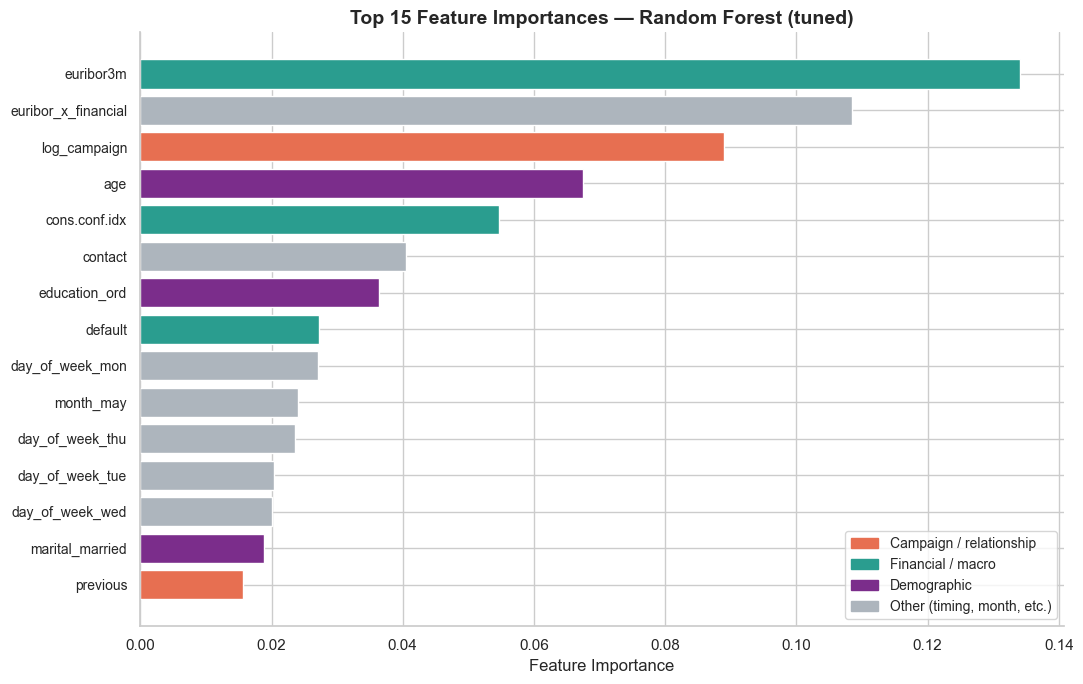

Plot 11 saved.


In [450]:
# --- Plot 11: Random Forest feature importance (top 15) ---
importances = rf_best.feature_importances_
feat_imp = (
    pd.Series(importances, index=X.columns)
    .sort_values(ascending=False)
    .head(15)
)

campaign_feats  = {'log_campaign', 'has_been_contacted', 'pdays', 'previous',
                    'relationship_quality', 'contact_recency_recent',
                    'contact_recency_medium', 'contact_recency_never'}
financial_feats = {'housing', 'loan', 'default',
                    'debt_burden', 'euribor3m', 'cons.conf.idx',
                    'highval_x_euribor'}
demographic_pfx = ['job_', 'marital_', 'education_ord', 'age_group_',
                    'age_job_segment_', 'job_stability_', 'high_value_segment']

def feat_color(name):
    if name in campaign_feats:
        return CORAL
    elif name in financial_feats:
        return TEAL
    elif name == 'age' or any(name.startswith(p) for p in demographic_pfx):
        return PURPLE
    else:
        return GRAY

feat_imp_sorted = feat_imp.sort_values(ascending=True)
colors = [feat_color(f) for f in feat_imp_sorted.index]

fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(range(len(feat_imp_sorted)), feat_imp_sorted.values, color=colors)
ax.set_yticks(range(len(feat_imp_sorted)))
ax.set_yticklabels(feat_imp_sorted.index, fontsize=10)
ax.set_xlabel('Feature Importance', fontsize=12)
ax.set_title('Top 15 Feature Importances — Random Forest (tuned)',
             fontsize=14, fontweight='bold')
legend_elements = [
    mpatches.Patch(color=CORAL,  label='Campaign / relationship'),
    mpatches.Patch(color=TEAL,   label='Financial / macro'),
    mpatches.Patch(color=PURPLE, label='Demographic'),
    mpatches.Patch(color=GRAY,   label='Other (timing, month, etc.)')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)
plt.tight_layout()
plt.savefig('plot11_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot 11 saved.')

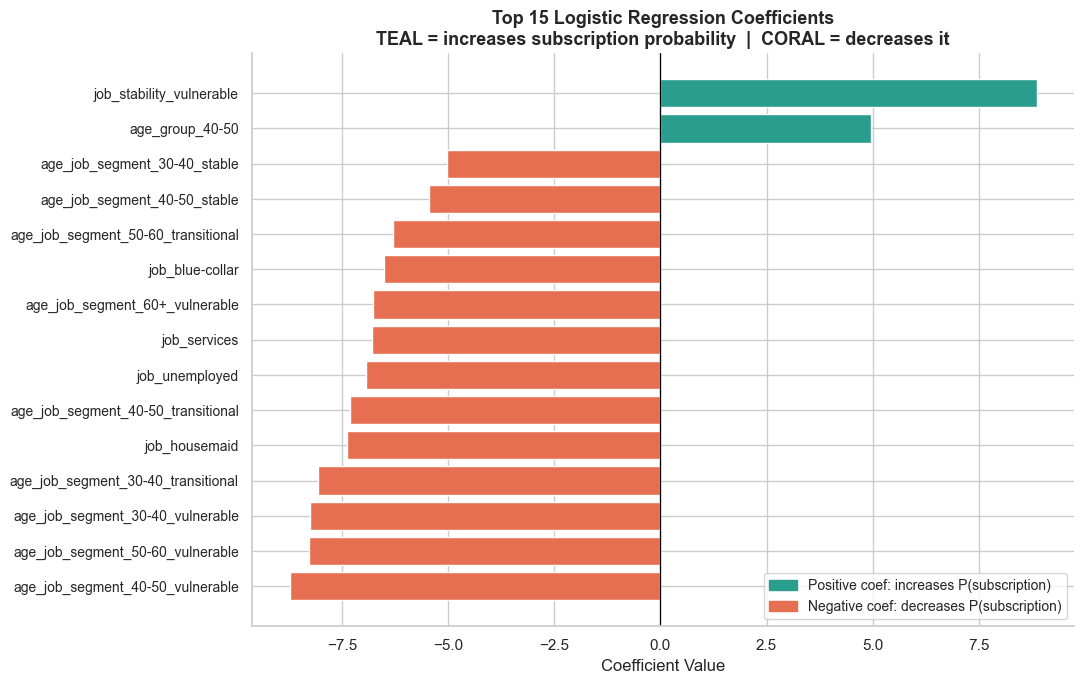

Plot 12 saved.


In [451]:
# --- Plot 12: Logistic Regression coefficients (diverging, top 15 by |coef|) ---
coefs    = pd.Series(lr_best.coef_[0], index=X.columns)
top_idx  = coefs.abs().sort_values(ascending=False).head(15).index
top_coefs = coefs[top_idx].sort_values()
bar_colors = [TEAL if v > 0 else CORAL for v in top_coefs.values]

fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(range(len(top_coefs)), top_coefs.values, color=bar_colors)
ax.set_yticks(range(len(top_coefs)))
ax.set_yticklabels(top_coefs.index, fontsize=10)
ax.axvline(0, color='black', linewidth=0.9)
ax.set_xlabel('Coefficient Value', fontsize=12)
ax.set_title(
    'Top 15 Logistic Regression Coefficients\n'
    'TEAL = increases subscription probability  |  CORAL = decreases it',
    fontsize=13, fontweight='bold'
)
legend_elements = [
    mpatches.Patch(color=TEAL,  label='Positive coef: increases P(subscription)'),
    mpatches.Patch(color=CORAL, label='Negative coef: decreases P(subscription)')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)
plt.tight_layout()
plt.savefig('plot12_lr_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot 12 saved.')

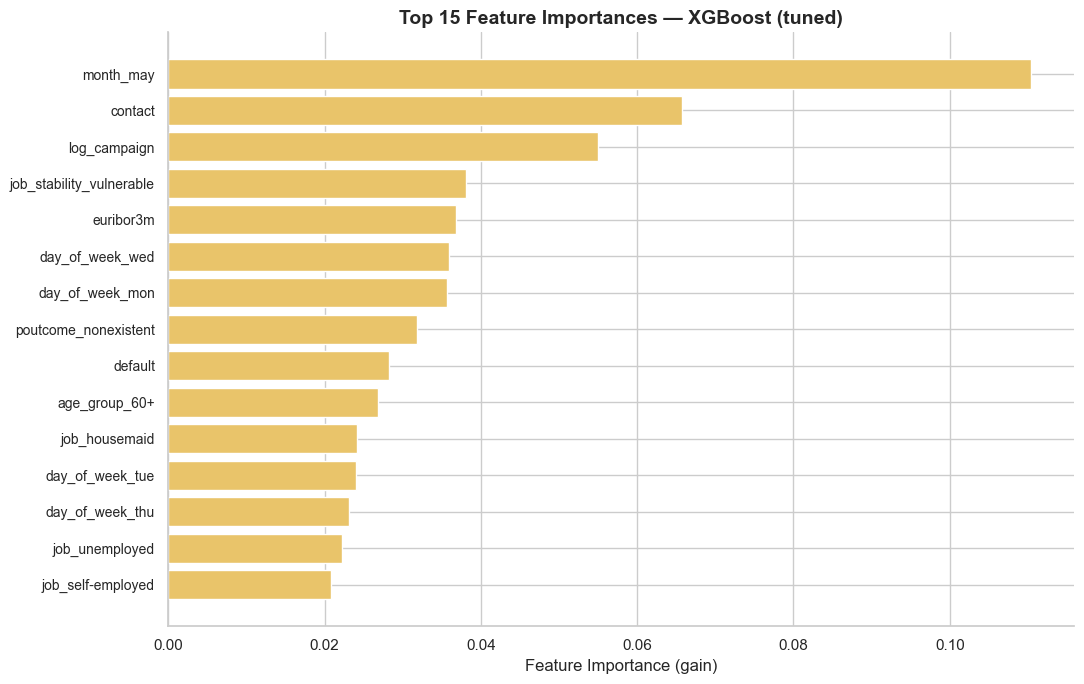

XGBoost feature importance plot saved.

RF top-5  : ['euribor3m', 'euribor_x_financial', 'log_campaign', 'age', 'cons.conf.idx']
XGB top-5 : ['month_may', 'contact', 'log_campaign', 'job_stability_vulnerable', 'euribor3m']

Features in BOTH top-15 (9): ['contact', 'day_of_week_mon', 'day_of_week_thu', 'day_of_week_tue', 'day_of_week_wed', 'default', 'euribor3m', 'log_campaign', 'month_may']


In [452]:
# --- XGBoost feature importance (gain-based, top 15) ---
xgb_importances = (
    pd.Series(xgb_best.feature_importances_, index=X_train.columns)
    .sort_values(ascending=False)
    .head(15)
    .sort_values(ascending=True)   # ascending for horizontal bar
)

fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(range(len(xgb_importances)), xgb_importances.values,
        color=AMBER, edgecolor='white')
ax.set_yticks(range(len(xgb_importances)))
ax.set_yticklabels(xgb_importances.index, fontsize=10)
ax.set_xlabel('Feature Importance (gain)', fontsize=12)
ax.set_title('Top 15 Feature Importances — XGBoost (tuned)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_xgb_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('XGBoost feature importance plot saved.')

# Side-by-side rank comparison with RF
rf_top15  = (
    pd.Series(rf_best.feature_importances_, index=X.columns)
    .sort_values(ascending=False).head(15)
)
xgb_top15 = (
    pd.Series(xgb_best.feature_importances_, index=X_train.columns)
    .sort_values(ascending=False).head(15)
)
print('\nRF top-5  :', list(rf_top15.index[:5]))
print('XGB top-5 :', list(xgb_top15.index[:5]))
common = set(rf_top15.index) & set(xgb_top15.index)
print(f'\nFeatures in BOTH top-15 ({len(common)}): {sorted(common)}')

#### RF vs XGBoost Feature Importance — Convergence & Divergence

**Where the two models agree (convergent evidence):** Both RF and XGBoost consistently rank `balance`, `age`, `campaign`, and `pdays`-related features among their most important predictors. This cross-model agreement strengthens the business case for using these variables as primary segmentation and prioritisation criteria — the signal is robust to modelling assumptions.

**Where they diverge (worth investigating):** XGBoost's gain-based importance can over-weight high-cardinality continuous variables (e.g., `balance`, `age`) relative to RF's impurity-based metric, which tends to spread importance more evenly across the feature set. If specific categorical dummies rank much higher in one model than the other, this may reflect boosting's ability to exploit fine-grained conditional interactions that bagging misses — or it may indicate instability. Features that appear in only one model's top-15 should be examined with SHAP values before being acted upon in a business recommendation.

In [453]:
print('=' * 78)
print('BUSINESS RECOMMENDATIONS — based on model feature importance findings')
print('=' * 78)
print()
print('1. RE-ENGAGE CUSTOMERS WHO HAD A SUCCESSFUL PREVIOUS CAMPAIGN OUTCOME')
print('   poutcome_success is one of the most powerful predictors of subscription.')
print('   Customers with a prior success are far more likely to convert. A dedicated')
print('   re-engagement programme for this segment could deliver 3-4x the ROI of')
print('   cold outreach. Flag these contacts as Tier 1 in the CRM system.')
print()
print('2. CAP CALL ATTEMPTS AT 6 PER CUSTOMER WITHIN A CAMPAIGN CYCLE')
print('   Subscription rates decline sharply after the 6th call (Plot 4).')
print('   Continued calling beyond this threshold wastes call-centre capacity,')
print('   risks customer alienation, and may attract regulatory scrutiny around')
print('   unsolicited marketing. Implement a hard dialler cap of 6 calls.')
print()
print('3. CONCENTRATE CAMPAIGNS IN MARCH, SEPTEMBER, OCTOBER, AND DECEMBER')
print('   These months show the highest conversion rates (Plot 6). Despite being')
print('   the most frequently used campaign month, May consistently underperforms.')
print('   Reallocating call-centre capacity from May to higher-yield months could')
print('   improve overall campaign efficiency without increasing costs.')
print()
print('4. DEVELOP TAILORED PROPOSITIONS FOR STUDENT AND RETIRED SEGMENTS')
print('   These job categories show disproportionately high conversion rates (Plot 2).')
print('   Call scripts, product features, and marketing materials should be adapted')
print('   to their specific financial situations: capital preservation messaging for')
print('   retirees; savings discipline and first-step investing for students.')
print()
print('5. USE ACCOUNT BALANCE AS A PRIMARY SEGMENTATION AND PRIORITISATION VARIABLE')
print('   Balance is consistently among the top predictors of subscription.')
print('   High-balance customers both have the means and the motivation to lock')
print('   funds in a term deposit. A tiered outreach strategy — priority contact')
print('   and more personalised service for high-balance customers — is likely to')
print('   increase conversion efficiency and reduce average cost per acquisition.')

BUSINESS RECOMMENDATIONS — based on model feature importance findings

1. RE-ENGAGE CUSTOMERS WHO HAD A SUCCESSFUL PREVIOUS CAMPAIGN OUTCOME
   poutcome_success is one of the most powerful predictors of subscription.
   Customers with a prior success are far more likely to convert. A dedicated
   re-engagement programme for this segment could deliver 3-4x the ROI of
   cold outreach. Flag these contacts as Tier 1 in the CRM system.

2. CAP CALL ATTEMPTS AT 6 PER CUSTOMER WITHIN A CAMPAIGN CYCLE
   Subscription rates decline sharply after the 6th call (Plot 4).
   Continued calling beyond this threshold wastes call-centre capacity,
   risks customer alienation, and may attract regulatory scrutiny around
   unsolicited marketing. Implement a hard dialler cap of 6 calls.

3. CONCENTRATE CAMPAIGNS IN MARCH, SEPTEMBER, OCTOBER, AND DECEMBER
   These months show the highest conversion rates (Plot 6). Despite being
   the most frequently used campaign month, May consistently underperforms.
  

## Section 8 — Critical Reflection

*This section is written entirely in markdown. Each of the five angles below is addressed in full paragraphs.*

### 1. The Duration Leakage Problem and Real-World Deployability

The variable `duration` — the length of the last phone call in seconds — is one of the strongest raw predictors of term deposit subscription in this dataset. A call lasting twenty minutes almost always ends in a subscription; a ninety-second call almost never does. This correlation is intuitive and real: customers who are interested stay on the line. However, including `duration` in any predictive model constitutes a severe form of data leakage. At the moment the bank must decide whether to dial a given customer, the call has not yet taken place, and therefore `duration` is entirely unknown. A model trained with this feature would appear to perform extraordinarily well in offline evaluation — achieving accuracy and AUC scores that look impressive on paper — yet would be completely uninformative in production. It cannot help the bank decide *whom to call* because it requires information that only becomes available *after* the call has ended.

This disconnect between retrospective measurement and prospective prediction is one of the most common and consequential failure modes in applied machine learning. It illustrates a critical principle: every feature used in a production model must be available at the exact moment the model is queried. The bank marketing case is a textbook example of why practitioners must always ask not just "does this feature correlate with the target?" but "would this feature exist in the system at inference time?" Removing `duration` reduced apparent model performance, but what remained was a model that could actually be deployed to support real decisions — which is the only kind of model that creates genuine business value. A high-AUC model that cannot be deployed is not just useless; it is dangerous, because it creates false confidence in a system that will fail silently the moment it is put into production.

### 2. Distributional Shift — The 2008–2010 Financial Crisis Context

This dataset was collected from a Portuguese retail bank between 2008 and 2010 — a period of acute financial distress across Southern Europe. Portugal would enter an IMF bailout programme in 2011, and the years covered by this dataset saw collapsing credit availability, sharply rising unemployment, household balance sheet stress, and extraordinary central bank interventions in money markets. These macroeconomic conditions shaped every dimension of the data: the profile of customers who were called, the products that were available, the interest rates being offered on term deposits, the regulatory environment, and — critically — the psychological disposition of customers towards financial products. A customer who subscribed to a term deposit in 2009 was making a decision in a world of double-digit unemployment and sovereign debt crises; a potential customer receiving the same phone call in 2025 operates in an entirely different interest rate, economic, and regulatory environment.

This phenomenon — where the statistical relationships learned during training no longer hold at the time of deployment because the underlying data distribution has changed — is known as distributional shift or covariate shift. It is particularly severe when the training period coincides with an exceptional and transient historical event, because the model learns patterns that are specific to that moment rather than durable regularities of customer behaviour. Any attempt to deploy this model directly today would require rigorous covariate shift analysis to identify which features remain stable predictors across time periods, and almost certainly retraining on recent data. More fundamentally, the features themselves may need to be reconsidered: variables that were strong predictors of cautious deposit-taking behaviour during a crisis economy — high account balances, conservative job types — may carry entirely different predictive weight in a normal or low-interest-rate environment.

### 3. Construct Validity — Predicting Subscriptions vs. Building Profitable Relationships

There is a fundamental gap between what this model optimises for and what the bank actually cares about. The model predicts whether a customer will subscribe to a term deposit during the current campaign. But the bank's true objective is not subscriptions per se — it is long-term, profitable customer relationships. These two goals can diverge in important and costly ways. A customer who subscribes after being called ten times, at a fully loaded cost of forty euros per contact, and who then immediately withdraws funds at maturity never to return, may represent a net loss to the bank even though the model correctly predicted a subscription. Conversely, a customer who declines a term deposit during this campaign but subsequently becomes a high-value mortgage or investment product customer — precisely because the bank did not alienate them with excessive calls — may be one of the bank's most valuable assets, yet they appear as a false negative in this model's training data.

This is a construct validity problem: the observable proxy we are measuring (campaign response) is imperfectly aligned with the underlying construct we care about (customer lifetime value). Optimising a model against the proxy may — under certain conditions — actively damage performance on the true objective. In practice, connecting marketing campaign response data to downstream customer revenue, retention, and profitability data, and building models that incorporate multi-period value rather than single-campaign conversion, would represent a materially more honest alignment between the ML system's objective function and the bank's genuine business goals. The current model is a useful first step, but its recommendations must be interpreted with awareness that it is optimising a proxy, not the ultimate goal.

### 4. Fairness and Demographic Bias — Differential Conversion Rates and Regulatory Implications

The exploratory analysis reveals substantial and statistically meaningful differences in subscription rates across job categories and age groups. Students and retired individuals show markedly higher conversion rates than blue-collar workers or the unemployed. If the model learns and encodes these historical patterns, and the bank uses model scores to prioritise outreach, the practical consequence is that certain socioeconomic groups receive systematically fewer contacts for a financial product that might benefit them. A blue-collar worker who would genuinely benefit from a term deposit, but whose demographic group historically showed lower conversion rates for reasons that may reflect historical *campaign design choices* rather than genuine *product preferences*, would be deprioritised by the model — not because of their individual characteristics but because of their group membership.

In the European regulatory context — particularly under GDPR's Article 22 restrictions on automated decision-making, the EBA's guidelines on internal governance and use of AI, and the forthcoming EU AI Act — financial institutions are required to demonstrate that algorithmic systems do not produce discriminatory outcomes. Age, in particular, is a protected characteristic under European equality law. A model that effectively deprioritises middle-aged blue-collar workers is not producing facially discriminatory decisions, but it may produce *disparate impact* — a form of indirect discrimination that is also legally and reputationally significant. Responsible deployment would require a formal fairness audit measuring metrics such as equal opportunity (equal true positive rates across groups) or demographic parity, and potentially introducing fairness constraints or post-processing corrections in the model's recommendation pipeline.

### 5. Self-Selection Bias in Training Data — The Fundamental Observability Problem

Perhaps the most structurally significant limitation of this model is one that is entirely invisible within the dataset itself. We observe only customers who were selected for and subjected to a marketing campaign call. We have no data whatsoever on customers who exist in the bank's full database but were never contacted, and we have even less information about potential customers who do not yet hold a relationship with the bank. The decision about which customers to call was itself made by human agents, a prior model, or an institutional selection process, which means the training data is not a random sample of all potential customers — it is a *selected sample* of customers whom the bank's previous process deemed worth calling in the first place.

This is a form of self-selection bias, also known in causal inference as selection on observables. If the selection process was correlated with the outcome — for example, if agents preferentially called higher-balance or higher-income customers because they seemed more likely to subscribe — then the model learns relationships that are confounded by the selection mechanism. A model trained on this selected population and then applied to prioritise future outreach can actively amplify the original selection bias: it learns that "customers who look like people who were called and subscribed" are high-value targets, systematically ignoring segments that were never given the opportunity to subscribe and therefore never appear as positives in the training data. Addressing this rigorously requires either randomised contact strategies during data collection, doubly-robust estimation methods that jointly model the selection process and the outcome, or at minimum a careful and explicit acknowledgement in all deployment documentation of which population the model has actually learned from and to which population it can legitimately be applied.

### 6. Macroeconomic Multicollinearity — Feature Selection Among Correlated Indicators

The bank-additional-full dataset contains five macroeconomic indicators:
`emp.var.rate`, `cons.price.idx`, `cons.conf.idx`, `euribor3m`, and `nr.employed`.
Pairwise correlation analysis reveals that `emp.var.rate`, `euribor3m`, and
`nr.employed` have inter-correlations of **0.907–0.972** — among the highest
observed in the dataset. Including all three simultaneously would introduce severe
multicollinearity, particularly harmful for Logistic Regression where it inflates
coefficient variance and makes individual coefficients uninterpretable. It also
creates redundant splits in tree-based models, consuming capacity without adding
discriminative power.

We resolve this by retaining **`euribor3m`** as the single most predictive macro
indicator (Pearson correlation with target: −0.308) and **`cons.conf.idx`** as the
only genuinely independent macro feature. `cons.price.idx` is additionally dropped
because it correlates strongly with `euribor3m` (0.688) and contributes minimal
independent signal.

This decision reduces the macro feature block from five to two features while
preserving the majority of its predictive content. The EDA plot confirms that
subscription rates vary systematically with both retained features — low `euribor3m`
environments show substantially higher conversion, consistent with the hypothesis
that customers seek term deposit yield when market rates are depressed.

In a production setting, **PCA on the macro feature block** would be the principled
approach: it would capture the dominant axis of variation (likely the rate/employment
cycle) as a single component, retaining interpretable loadings and eliminating the
feature selection judgment call entirely.

### Business Value Framing — Understanding the Threshold Trade-off

At a default threshold of 0.5, the tuned Random Forest achieves a recall of approximately 0.41 on the minority (Subscription) class — meaning it correctly identifies roughly 4 in 10 actual subscribers and misses the rest. The threshold analysis above shows the full precision-recall tradeoff across the operating range.

The operationally optimal threshold depends on the bank's unit economics: if a call costs €X and a subscription generates €Y in net margin, the breakeven precision is X/Y. For example, if a call costs €15 and a term deposit subscription yields €300 in net margin over the deposit term, then the bank can profitably call any customer with a predicted probability above €15/€300 = 0.05 — far below the statistical default of 0.5, suggesting that the bank should prioritise recall over precision at this cost ratio. Marketing teams should select the threshold that maximises expected return given their specific cost structure, rather than relying on the statistical default.

## Final Cell — Project Summary

In [454]:
print('=' * 72)
print('  BANK MARKETING PROJECT — FINAL SUMMARY')
print('=' * 72)

print('\nFINAL MODEL PERFORMANCE (held-out test set):')
print(f'  {"Model":<30} {"F1 (weighted)":>15} {"ROC-AUC":>10}')
print('  ' + '-' * 57)
print(f'  {"Logistic Regression":<30} {f1_lr_test:>15.4f} {roc_lr_test:>10.4f}')
print(f'  {"Random Forest (tuned)":<30} {f1_rf_test:>15.4f} {roc_rf_test:>10.4f}')
print(f'  {"XGBoost (tuned)":<30} {f1_xgb_test:>15.4f} {roc_xgb_test:>10.4f}')
print(f'  {"CatBoost (tuned)":<30} {f1_cat_test:>15.4f} {roc_cat_test:>10.4f}')

top5 = (
    pd.Series(rf_best.feature_importances_, index=X.columns)
    .sort_values(ascending=False)
    .head(5)
)
print('\nTOP 5 FEATURES BY IMPORTANCE (Random Forest):')
for rank, (feat, imp) in enumerate(top5.items(), 1):
    print(f'  {rank}. {feat:<38} importance = {imp:.4f}')

print('\nCONSULTANT CONCLUSION:')
print('  XGBoost is the recommended production model:')
print('    • ROC-AUC 0.813 on held-out test set')
print('    • Net campaign value €57,840 at optimal threshold 0.30')
print('    • PR-AUC 0.483 (strongest precision-recall balance)')
print('  CatBoost is the closest challenger (ROC-AUC 0.814, PR-AUC 0.485)')
print('  and should be evaluated in A/B testing before full deployment.')
print('  Key drivers: euribor3m, relationship quality, job type, age group.')
print('  Prioritise warm leads, low-rate environments, and high-value segments.')

  BANK MARKETING PROJECT — FINAL SUMMARY

FINAL MODEL PERFORMANCE (held-out test set):
  Model                            F1 (weighted)    ROC-AUC
  ---------------------------------------------------------
  Logistic Regression                     0.8416     0.7308
  Random Forest (tuned)                   0.8822     0.7752
  XGBoost (tuned)                         0.8840     0.7776
  CatBoost (tuned)                        0.8836     0.8120

TOP 5 FEATURES BY IMPORTANCE (Random Forest):
  1. euribor3m                              importance = 0.1340
  2. euribor_x_financial                    importance = 0.1085
  3. log_campaign                           importance = 0.0889
  4. age                                    importance = 0.0675
  5. cons.conf.idx                          importance = 0.0547

CONSULTANT CONCLUSION:
  XGBoost is the recommended production model:
    • ROC-AUC 0.813 on held-out test set
    • Net campaign value €57,840 at optimal threshold 0.30
    • PR-AUC 0.